# Python 绘图模块

## 库

In [1]:
import sys
sys.path.append(r"/Users/bzhouha/opt/petsc/lib/petsc/bin")
import numpy as np
import PetscBinaryIO
import matplotlib.pyplot as plt
import h5py
np.set_printoptions(precision=16)

## Size

In [2]:
In = 301
Jn = 501
Kn = 1

## Binary

### Binary Mesh 函数
* **filename** : 文件地址
* **data** : numpy.ndarray

In [3]:
def BinaryMesh(filename,data):
    io = PetscBinaryIO.PetscBinaryIO()
    fh = open(filename)
    obtype = io.readObjectType(fh)
    if obtype == 'Vec':
        v = io.readVec(fh)
    vec = np.array(v).reshape(Kn,Jn,In,3)
    for k in range(Kn):
        for j in range(Jn):
            for i in range(In):
                data[0,i,j,k] = vec[k,j,i,0].real
                data[1,i,j,k] = vec[k,j,i,1].real           
                data[2,i,j,k] = vec[k,j,i,2].real          
    return 0

### Binary Result 函数
* **filename** : 文件地址
* **data** : numpy.ndarray

In [4]:
def BinaryResult(filename,data):
    io = PetscBinaryIO.PetscBinaryIO()
    fh = open(filename)
    obtype = io.readObjectType(fh)
    if obtype == 'Vec':
        v = io.readVec(fh)
    vec = np.array(v).reshape(Kn,Jn,In,5)
    for k in range(Kn):
        for j in range(Jn):
            for i in range(In):
                data[0,i,j,k] = vec[k,j,i,0]
                data[1,i,j,k] = vec[k,j,i,1]                
                data[2,i,j,k] = vec[k,j,i,2]                
                data[3,i,j,k] = vec[k,j,i,3]                
                data[4,i,j,k] = vec[k,j,i,4]
    return 0

## HDF5

### HDF5 函数
* **filename** : 文件地址
* **baseflow** : numpy.ndarray
* **mesh** : numpy.ndarray
* **result** : numpy.ndarray

In [5]:
def HDF5file(filename,baseflow,mesh,result):
    f = h5py.File(filename,"r")
    
    if type(baseflow) is np.ndarray:
        data1r = np.array(f['baseflow'][:,:,:,:,0])
        data1i = np.array(f['baseflow'][:,:,:,:,1])
        data1 = np.zeros((Kn,Jn,In,5),np.complex128)
        data1 = data1r + 1j*data1i
        for k in range(Kn):
            for j in range(Jn):
                for i in range(In):
                    baseflow[0,i,j,k] = data1[k,j,i,0]
                    baseflow[1,i,j,k] = data1[k,j,i,1]                    
                    baseflow[2,i,j,k] = data1[k,j,i,2]                    
                    baseflow[3,i,j,k] = data1[k,j,i,3]                    
                    baseflow[4,i,j,k] = data1[k,j,i,4] 

    if type(mesh) is np.ndarray:
        data2r = np.array(f['grid'][:,:,:,:,0])
        for k in range(Kn):
            for j in range(Jn):
                for i in range(In):
                    mesh[0,i,j,k] = data2r[k,j,i,0]
                    mesh[1,i,j,k] = data2r[k,j,i,1]            
                    mesh[2,i,j,k] = data2r[k,j,i,2] 
      
    if type(result) is np.ndarray:
        data3r = np.array(f['hlns'][:,:,:,:,0])
        data3i = np.array(f['hlns'][:,:,:,:,1])
        data3 = np.zeros((Kn,Jn,In,5),np.complex128)
        data3 = data3r + 1j*data3i
        for k in range(Kn):
            for j in range(Jn):
                for i in range(In):
                    result[0,i,j,k] = data3[k,j,i,0]
                    result[1,i,j,k] = data3[k,j,i,1]                    
                    result[2,i,j,k] = data3[k,j,i,2]                    
                    result[3,i,j,k] = data3[k,j,i,3]                    
                    result[4,i,j,k] = data3[k,j,i,4]
                
    f.close()
    return 0

## 示例
### 读取

In [6]:
h_baseflow = np.zeros((5,In,Jn,Kn),np.complex128)
h_mesh = np.zeros((3,In,Jn,Kn),np.float64)
h_result = np.zeros((5,In,Jn,Kn),np.complex128)

p_baseflow = np.zeros((5,In,Jn,Kn),np.complex128)
p_mesh = np.zeros((3,In,Jn,Kn),np.float64)
p_result = np.zeros((5,In,Jn,Kn),np.complex128)

ierr = HDF5file('hlns.h5',h_baseflow,h_mesh,h_result)

ierr = BinaryMesh('grid.pet',p_mesh)
ierr = BinaryResult('flow.pet',p_baseflow)
ierr = BinaryResult('turtle.pet',p_result)

### 绘图

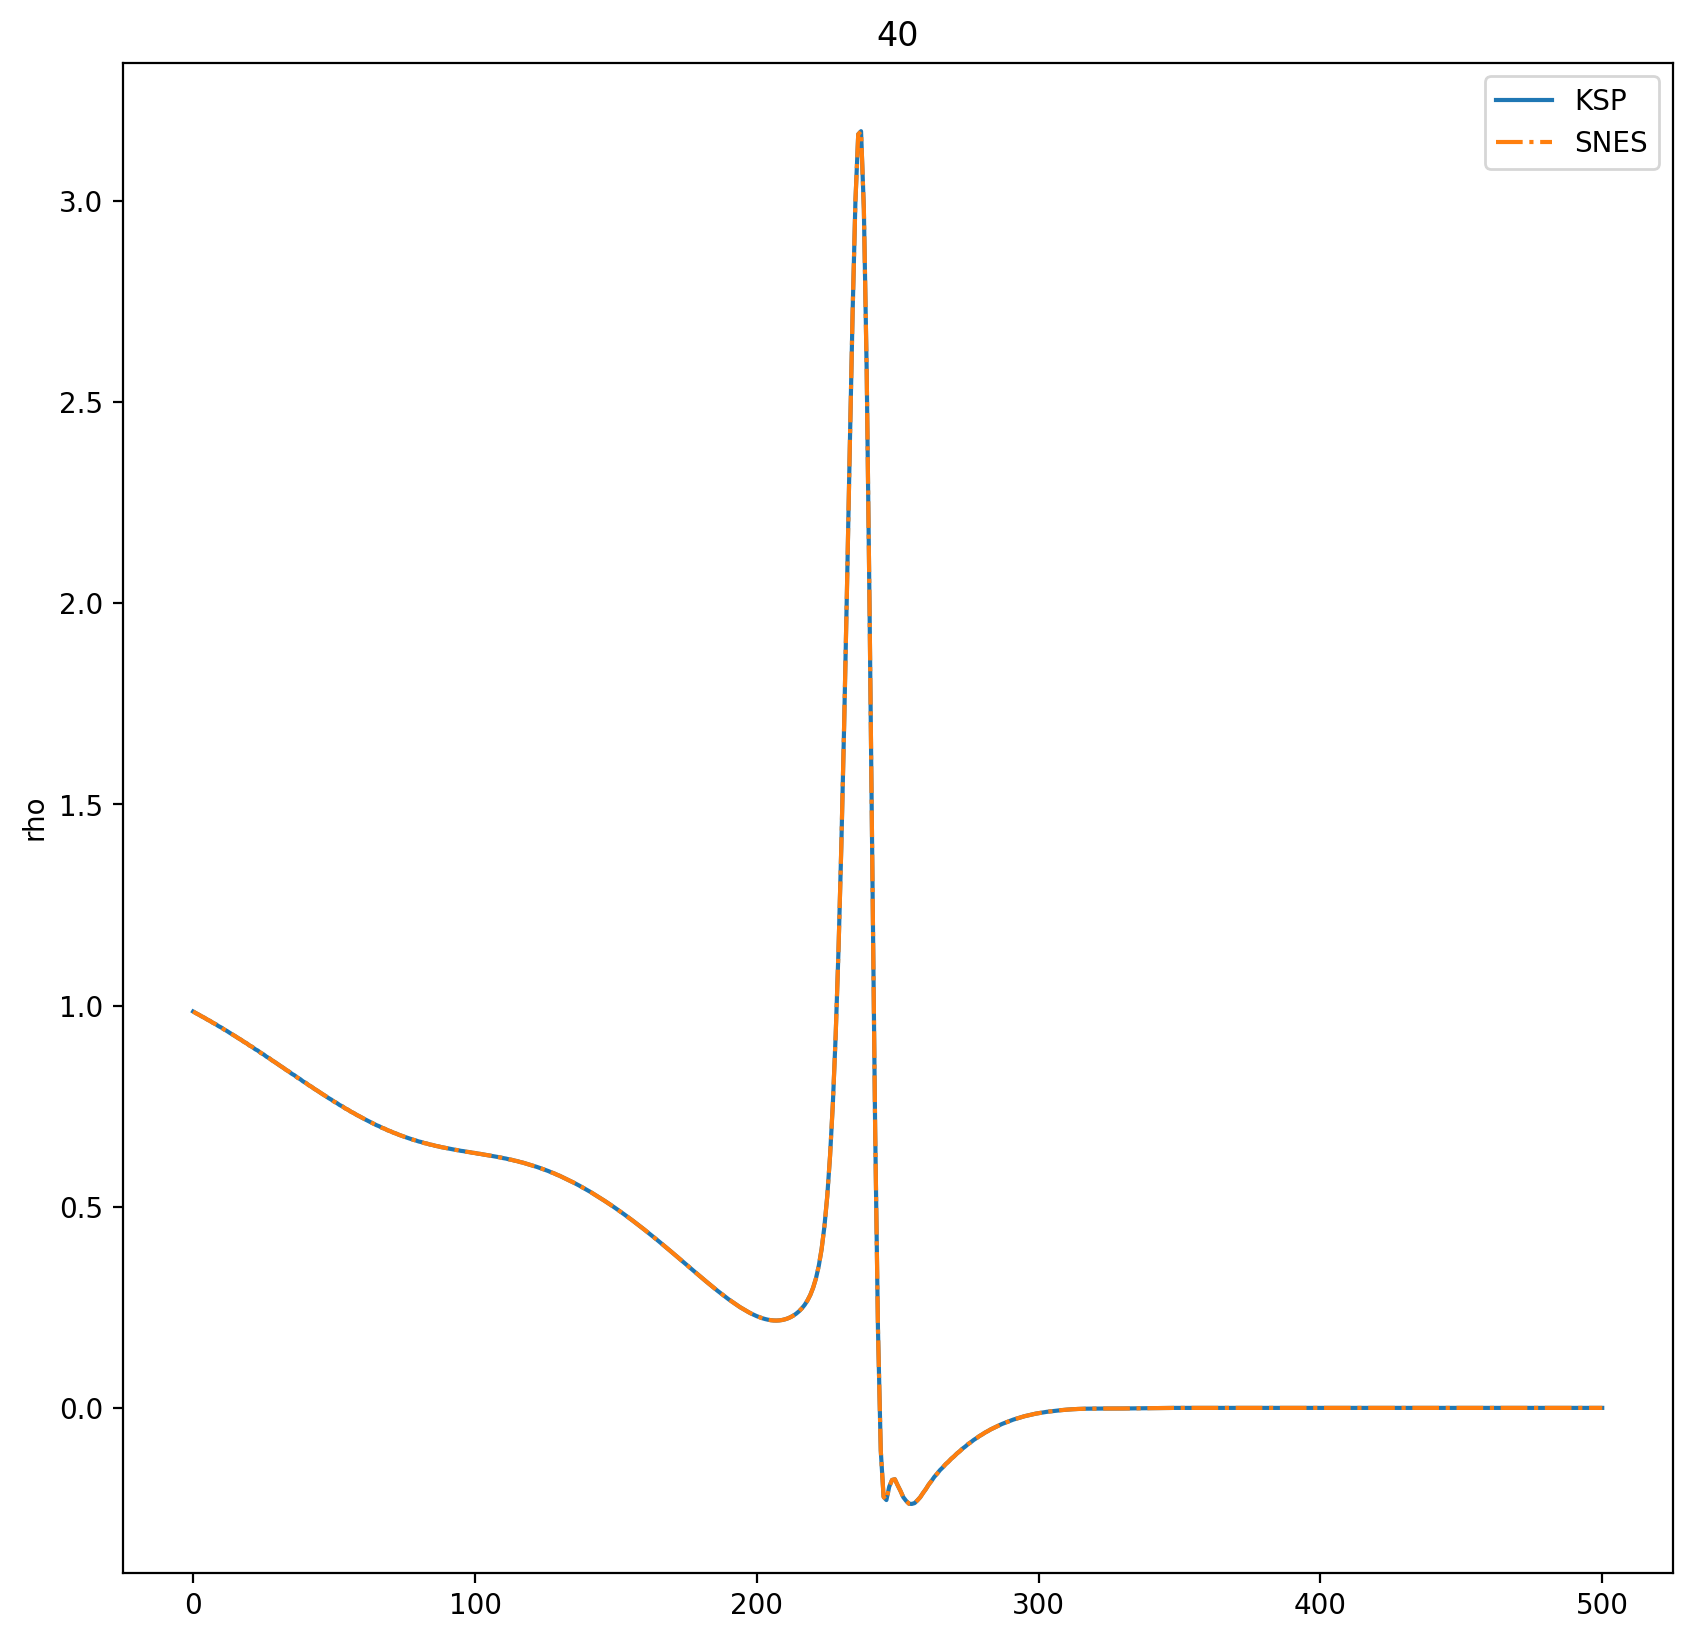

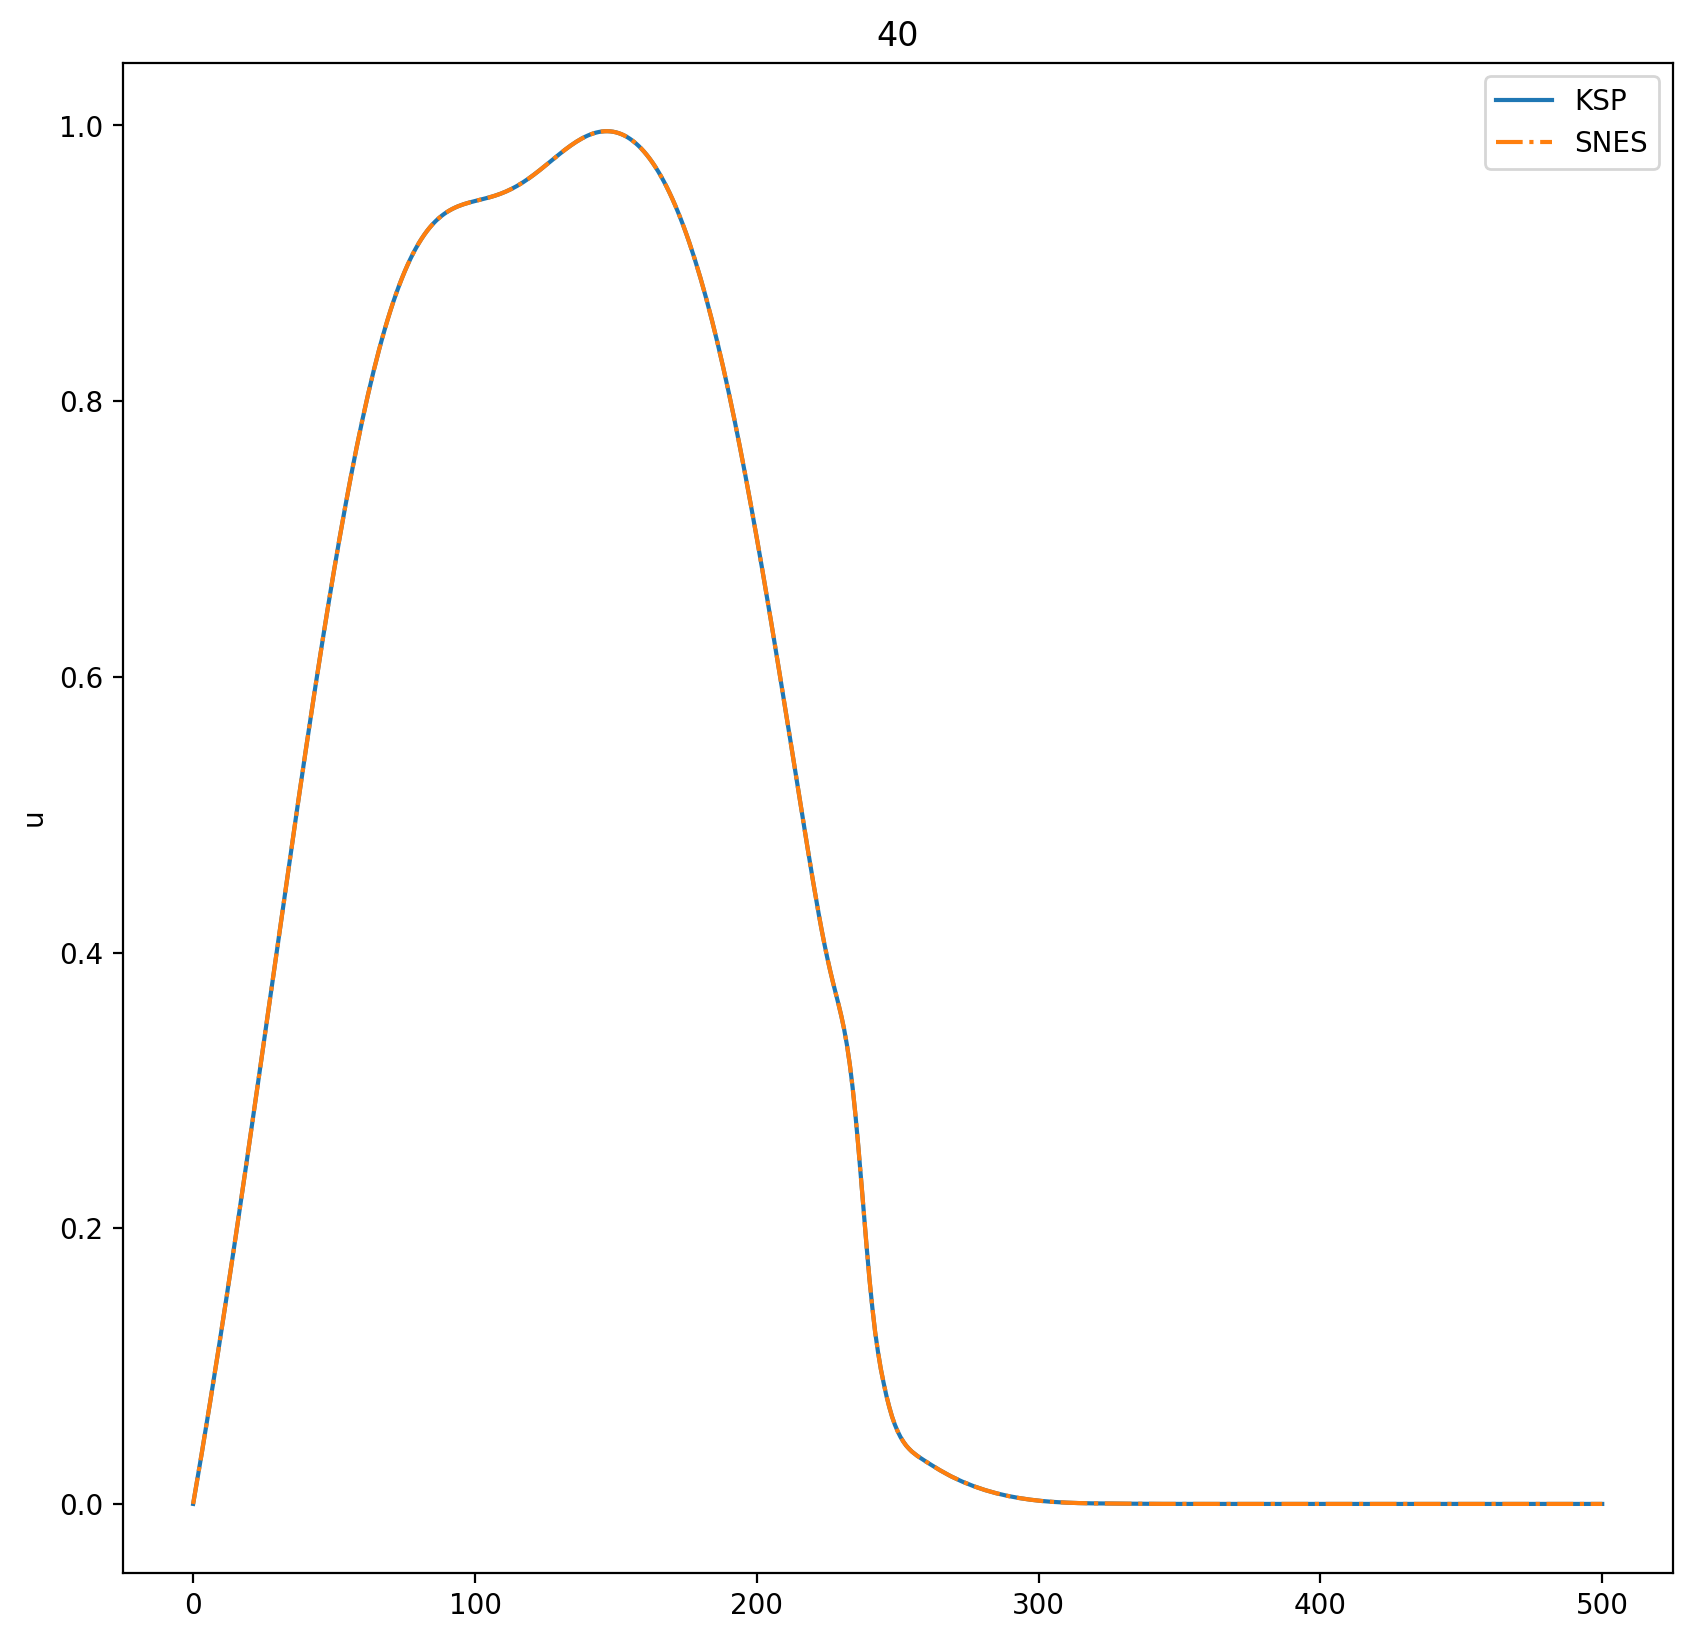

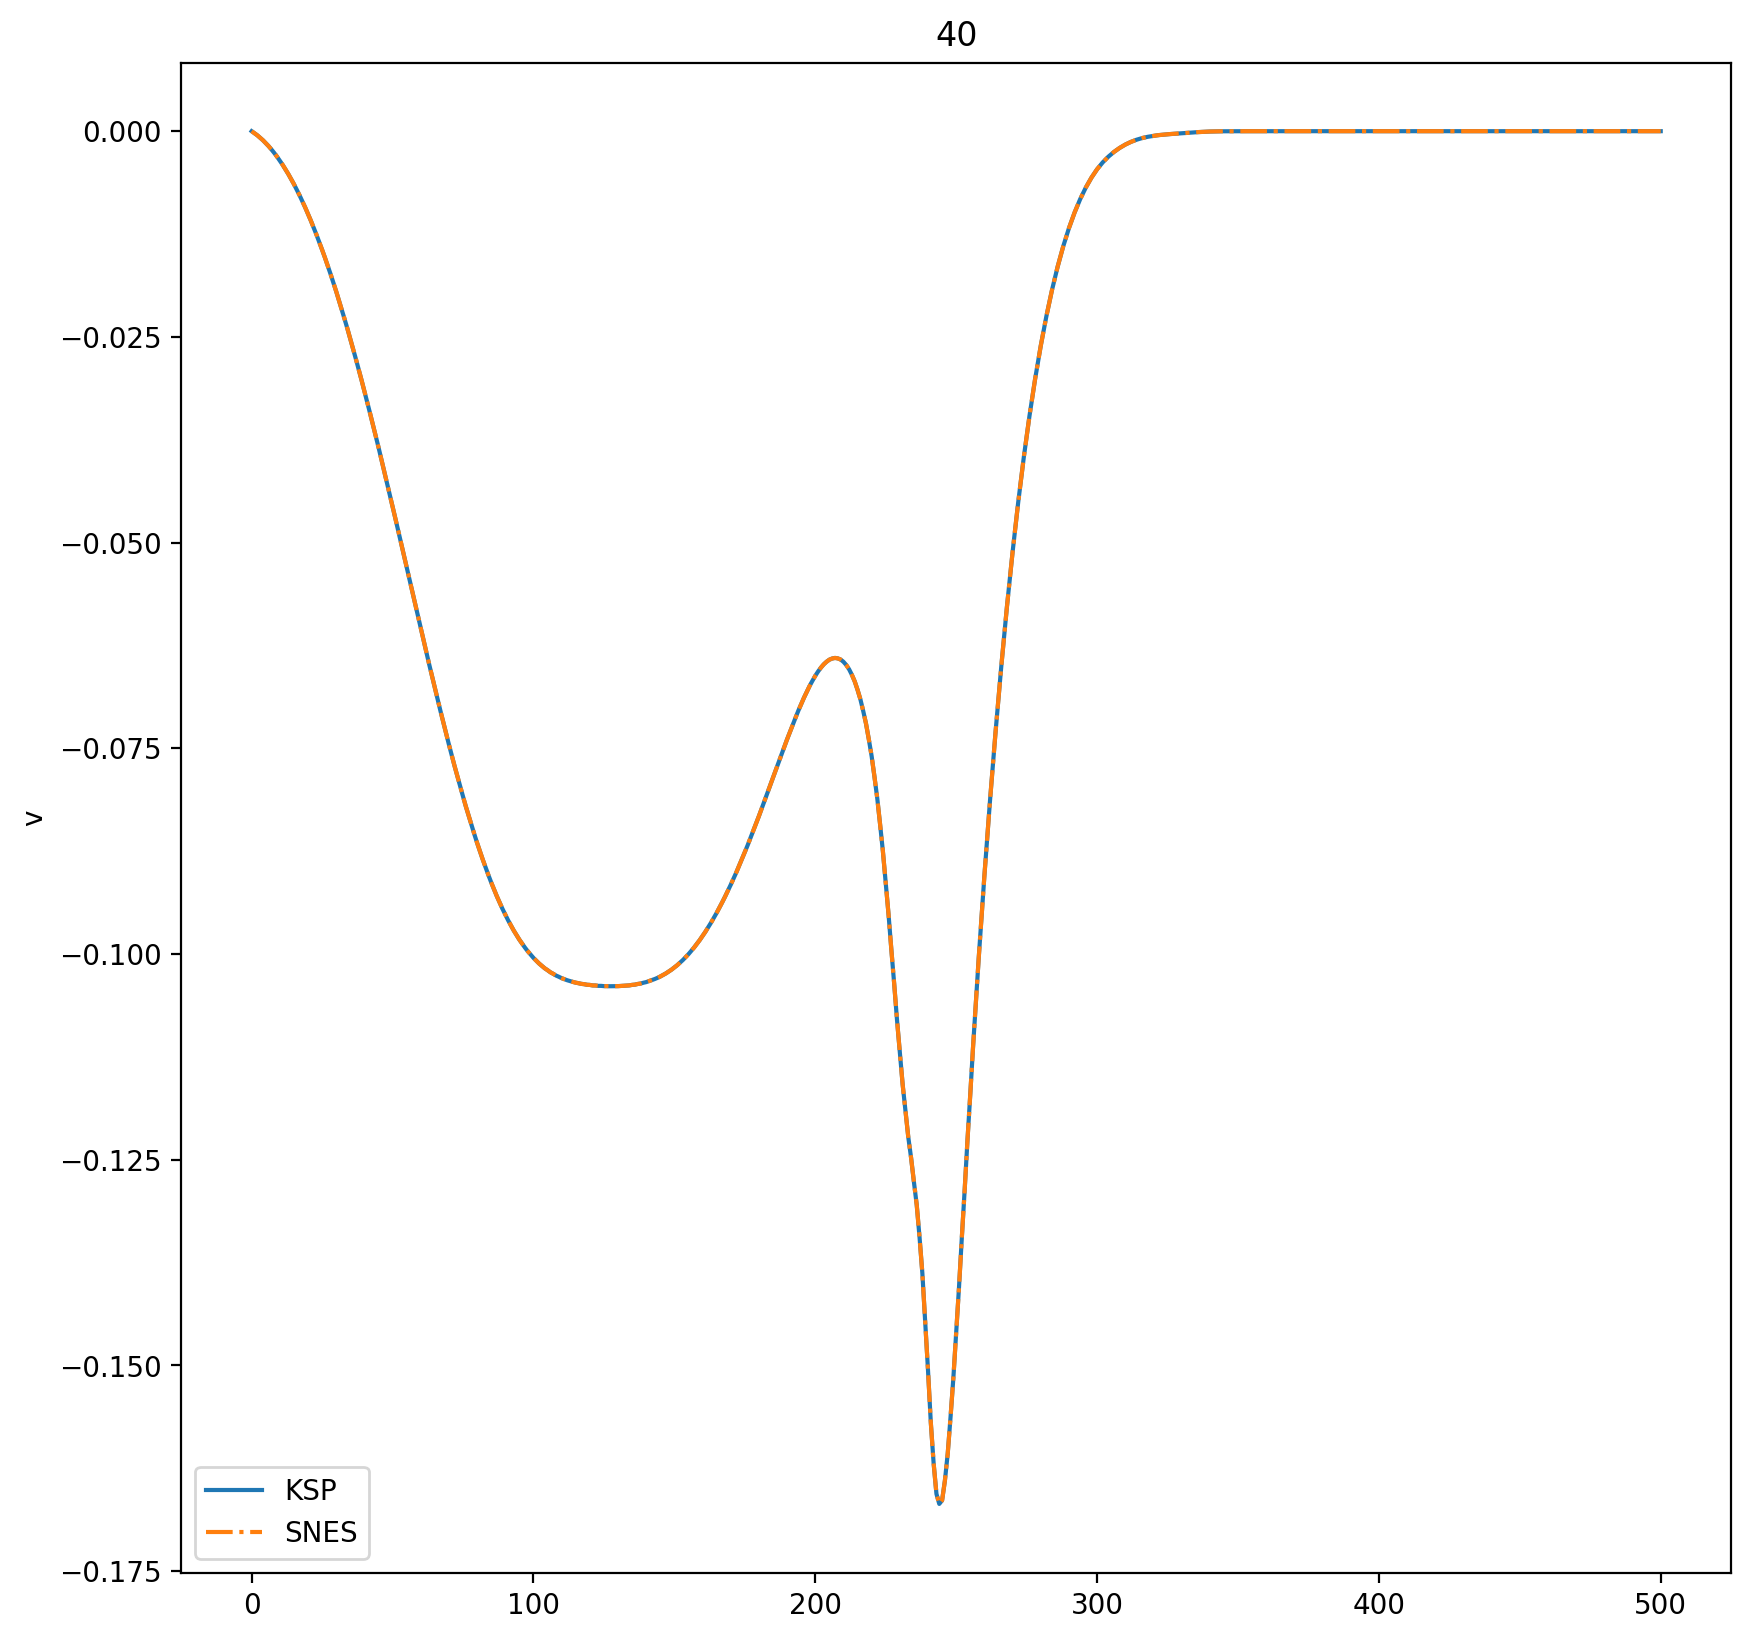

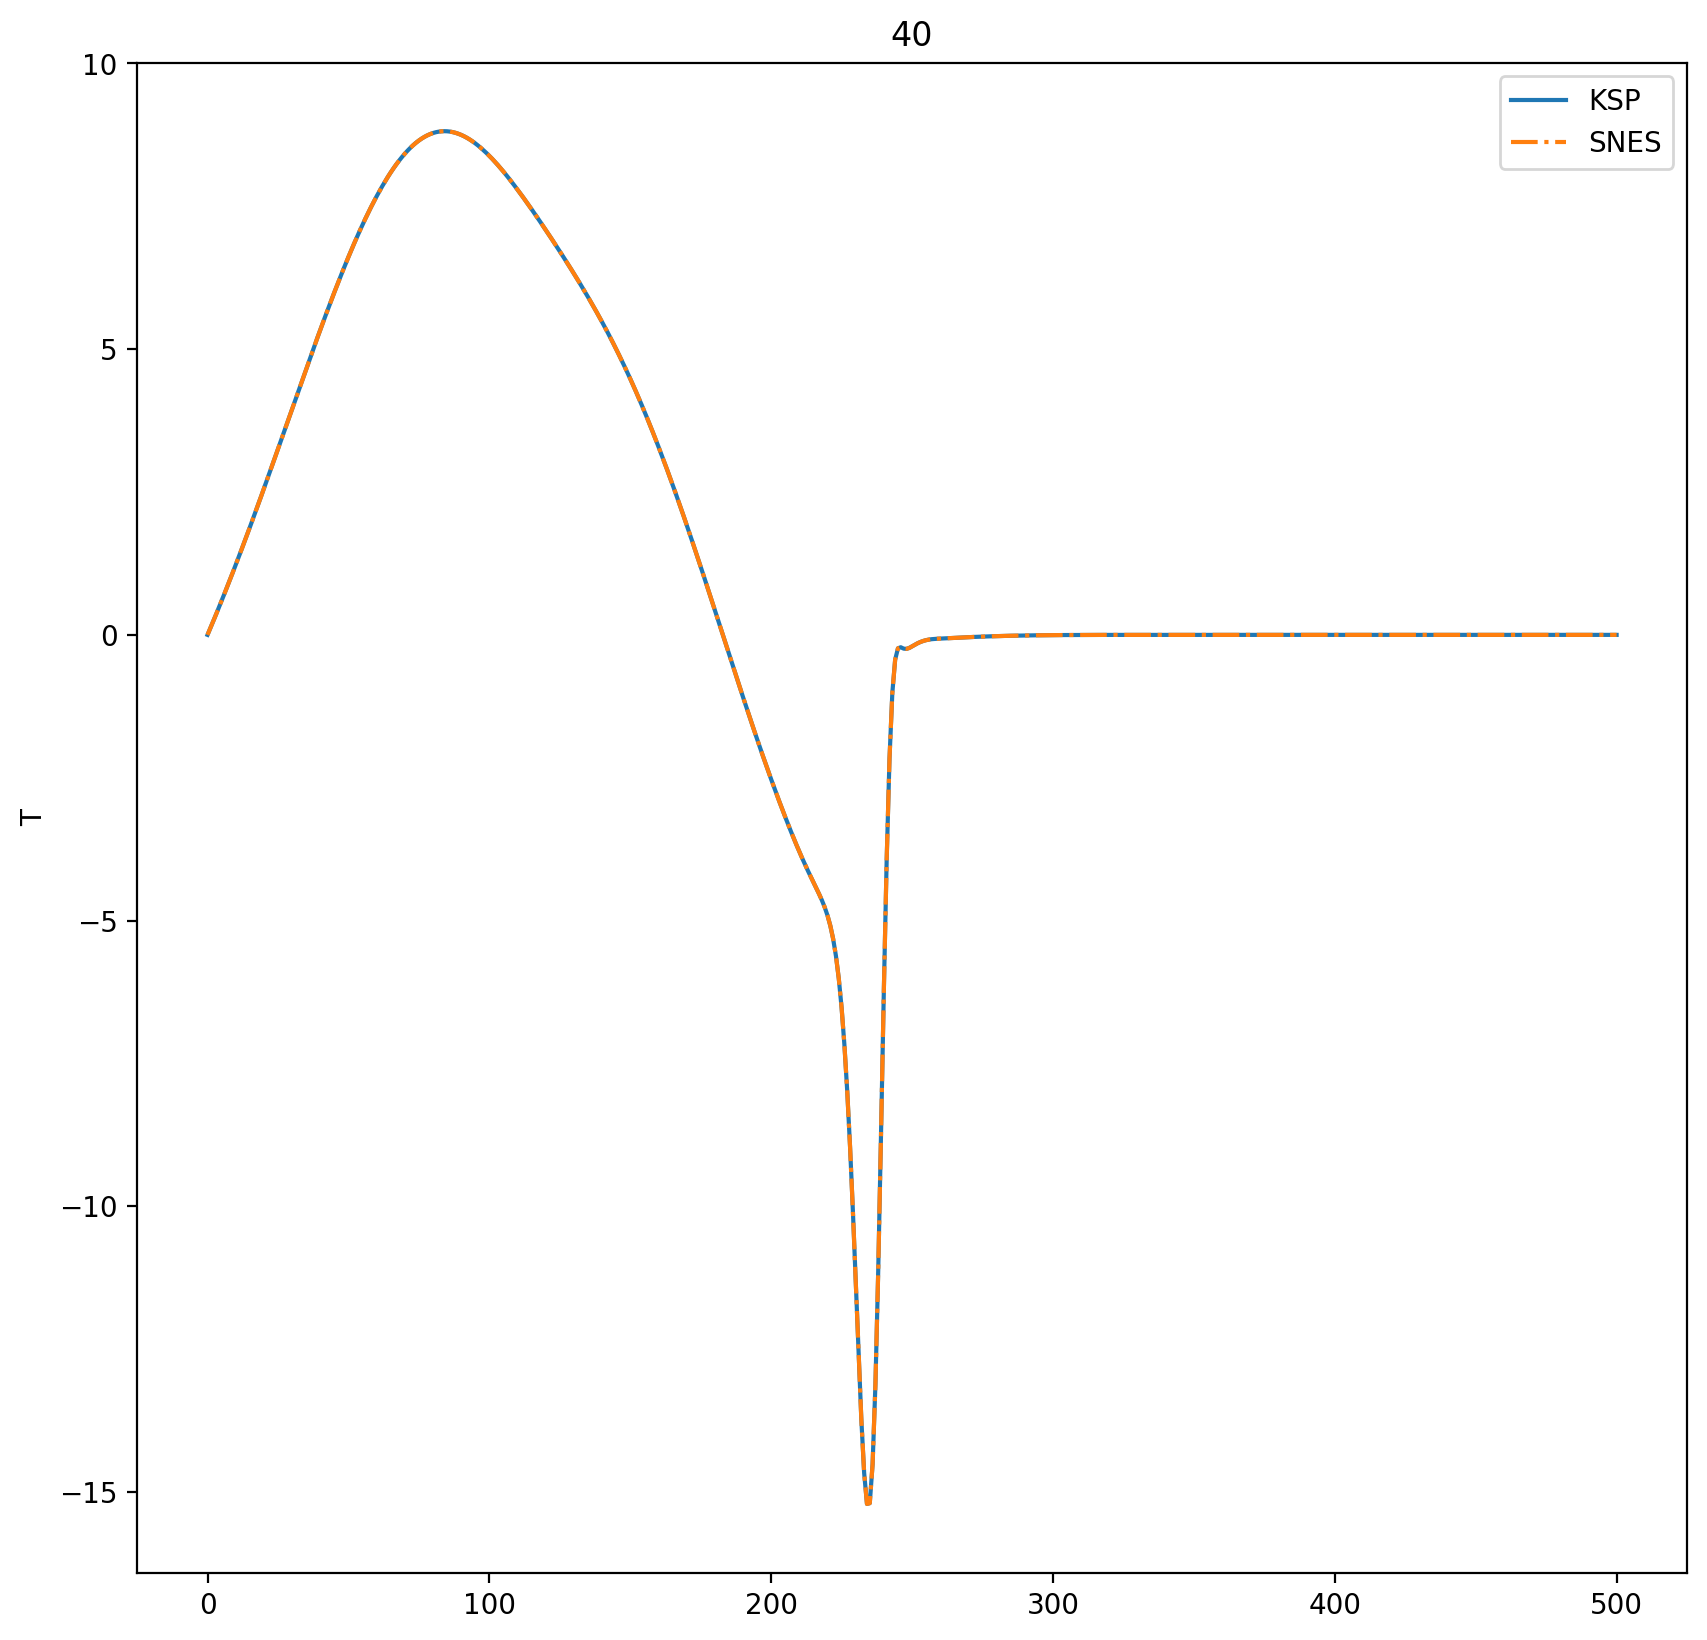

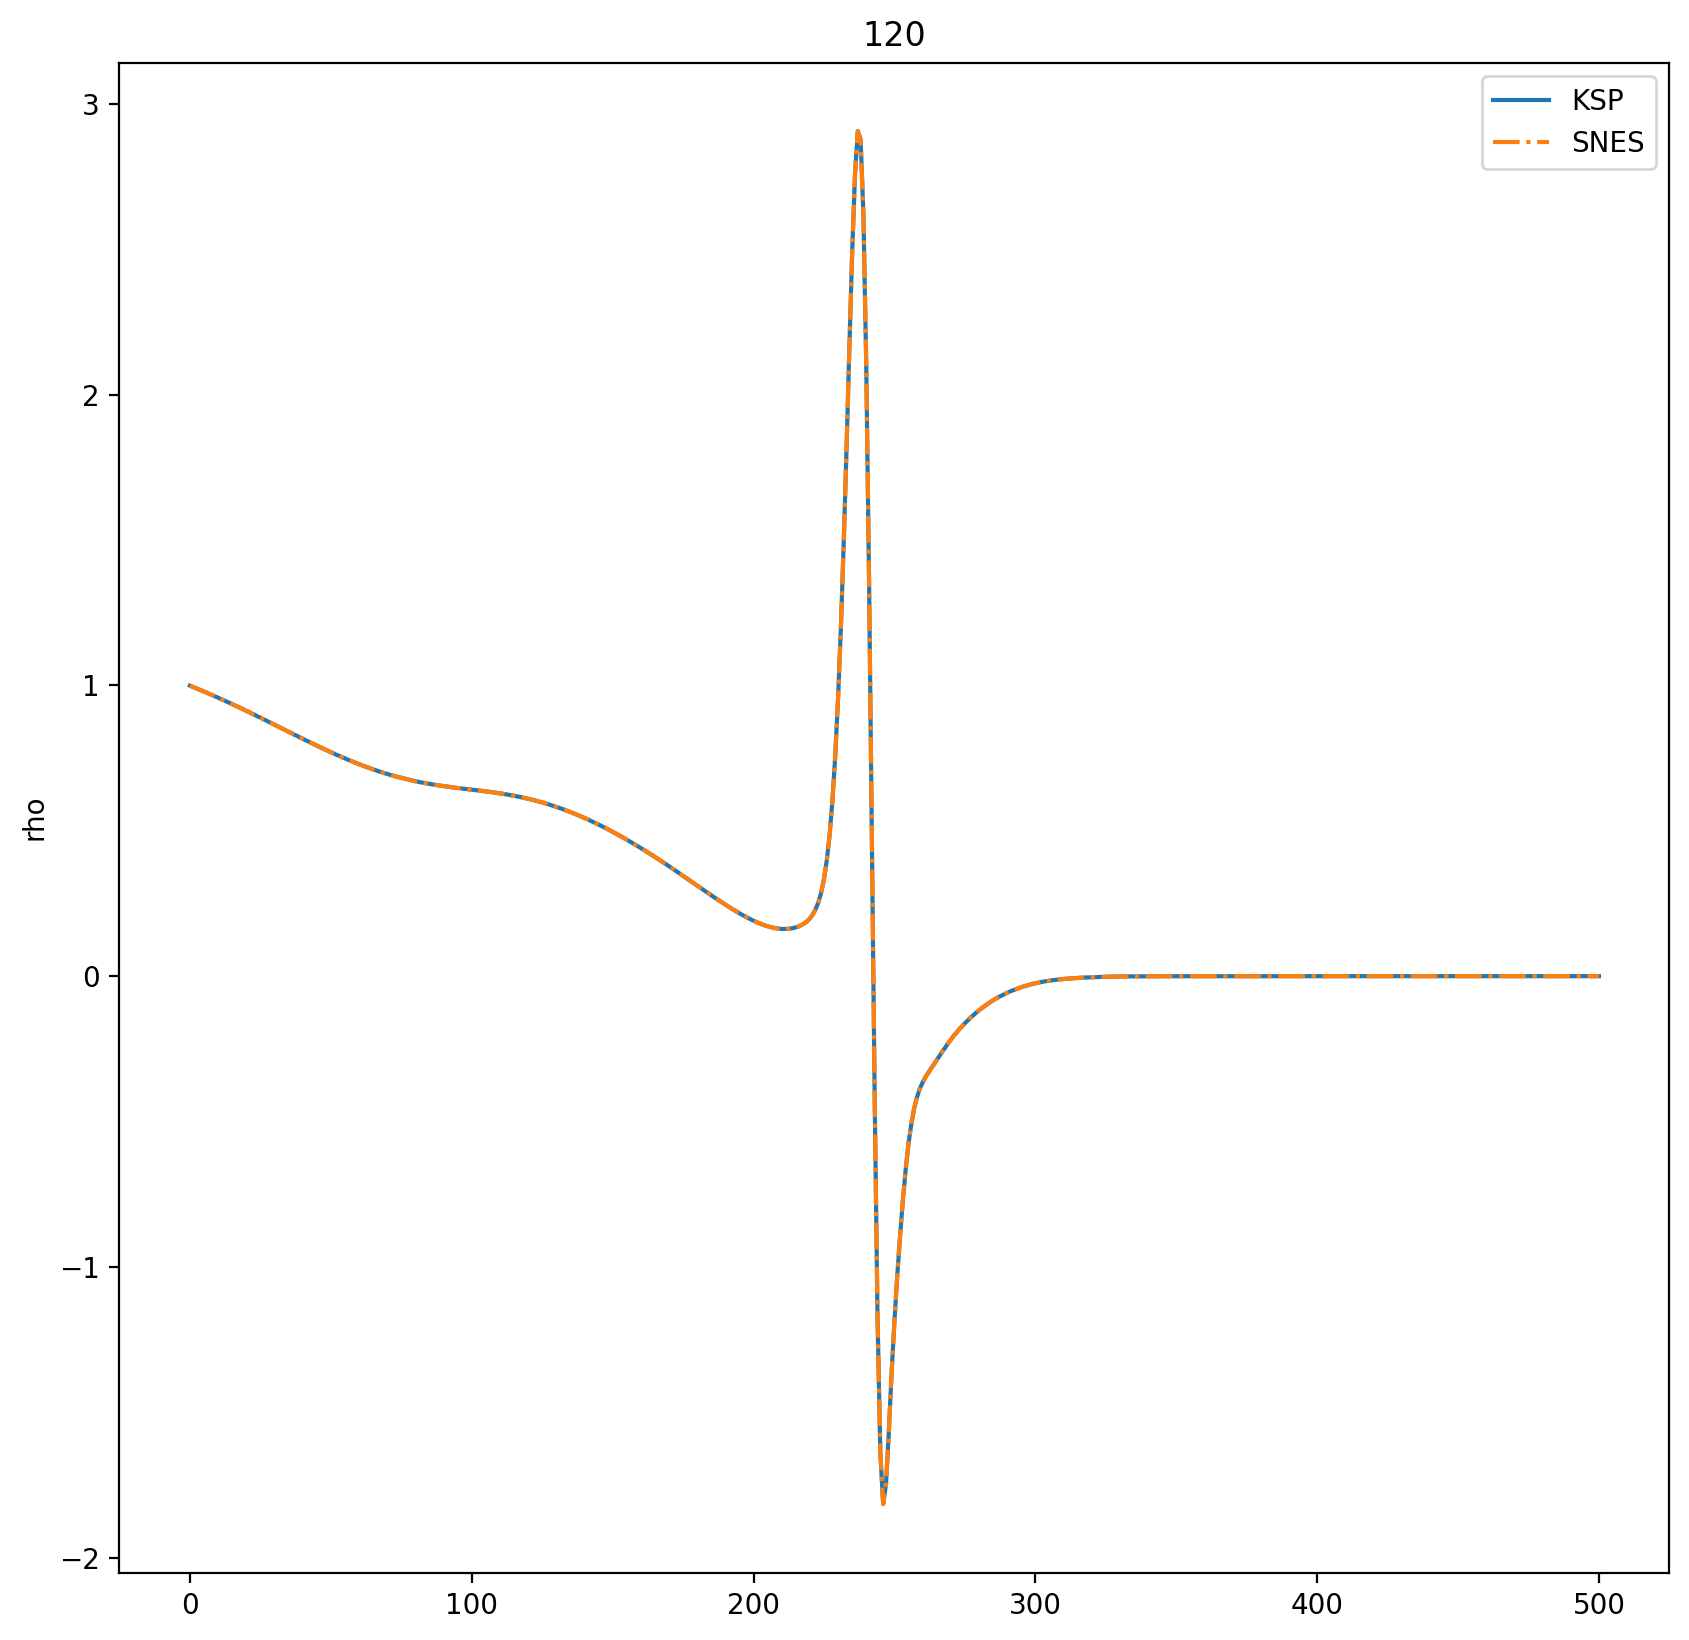

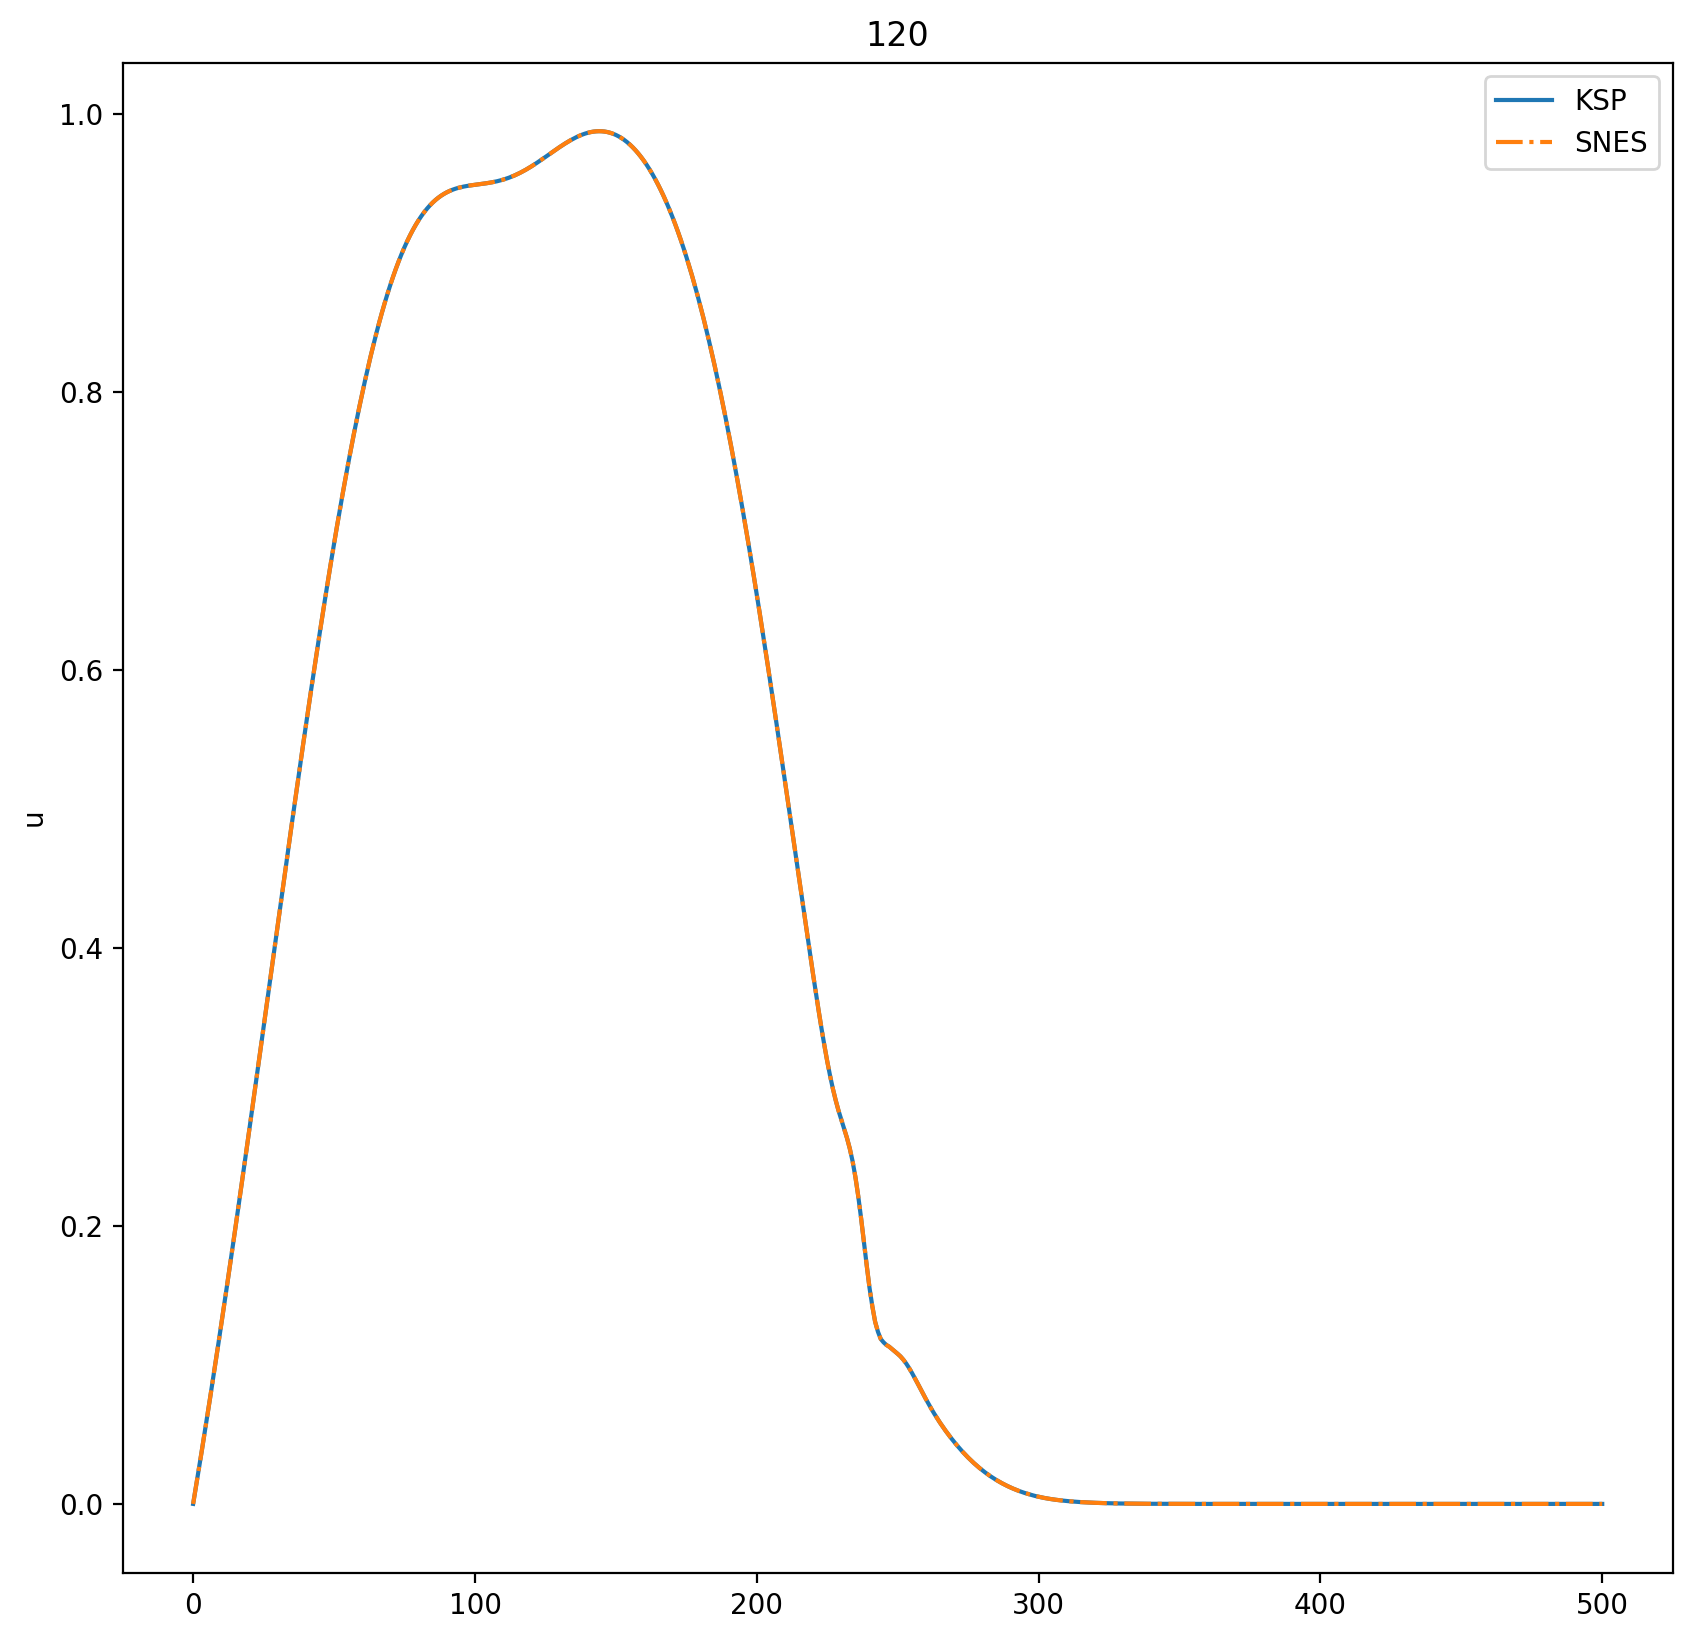

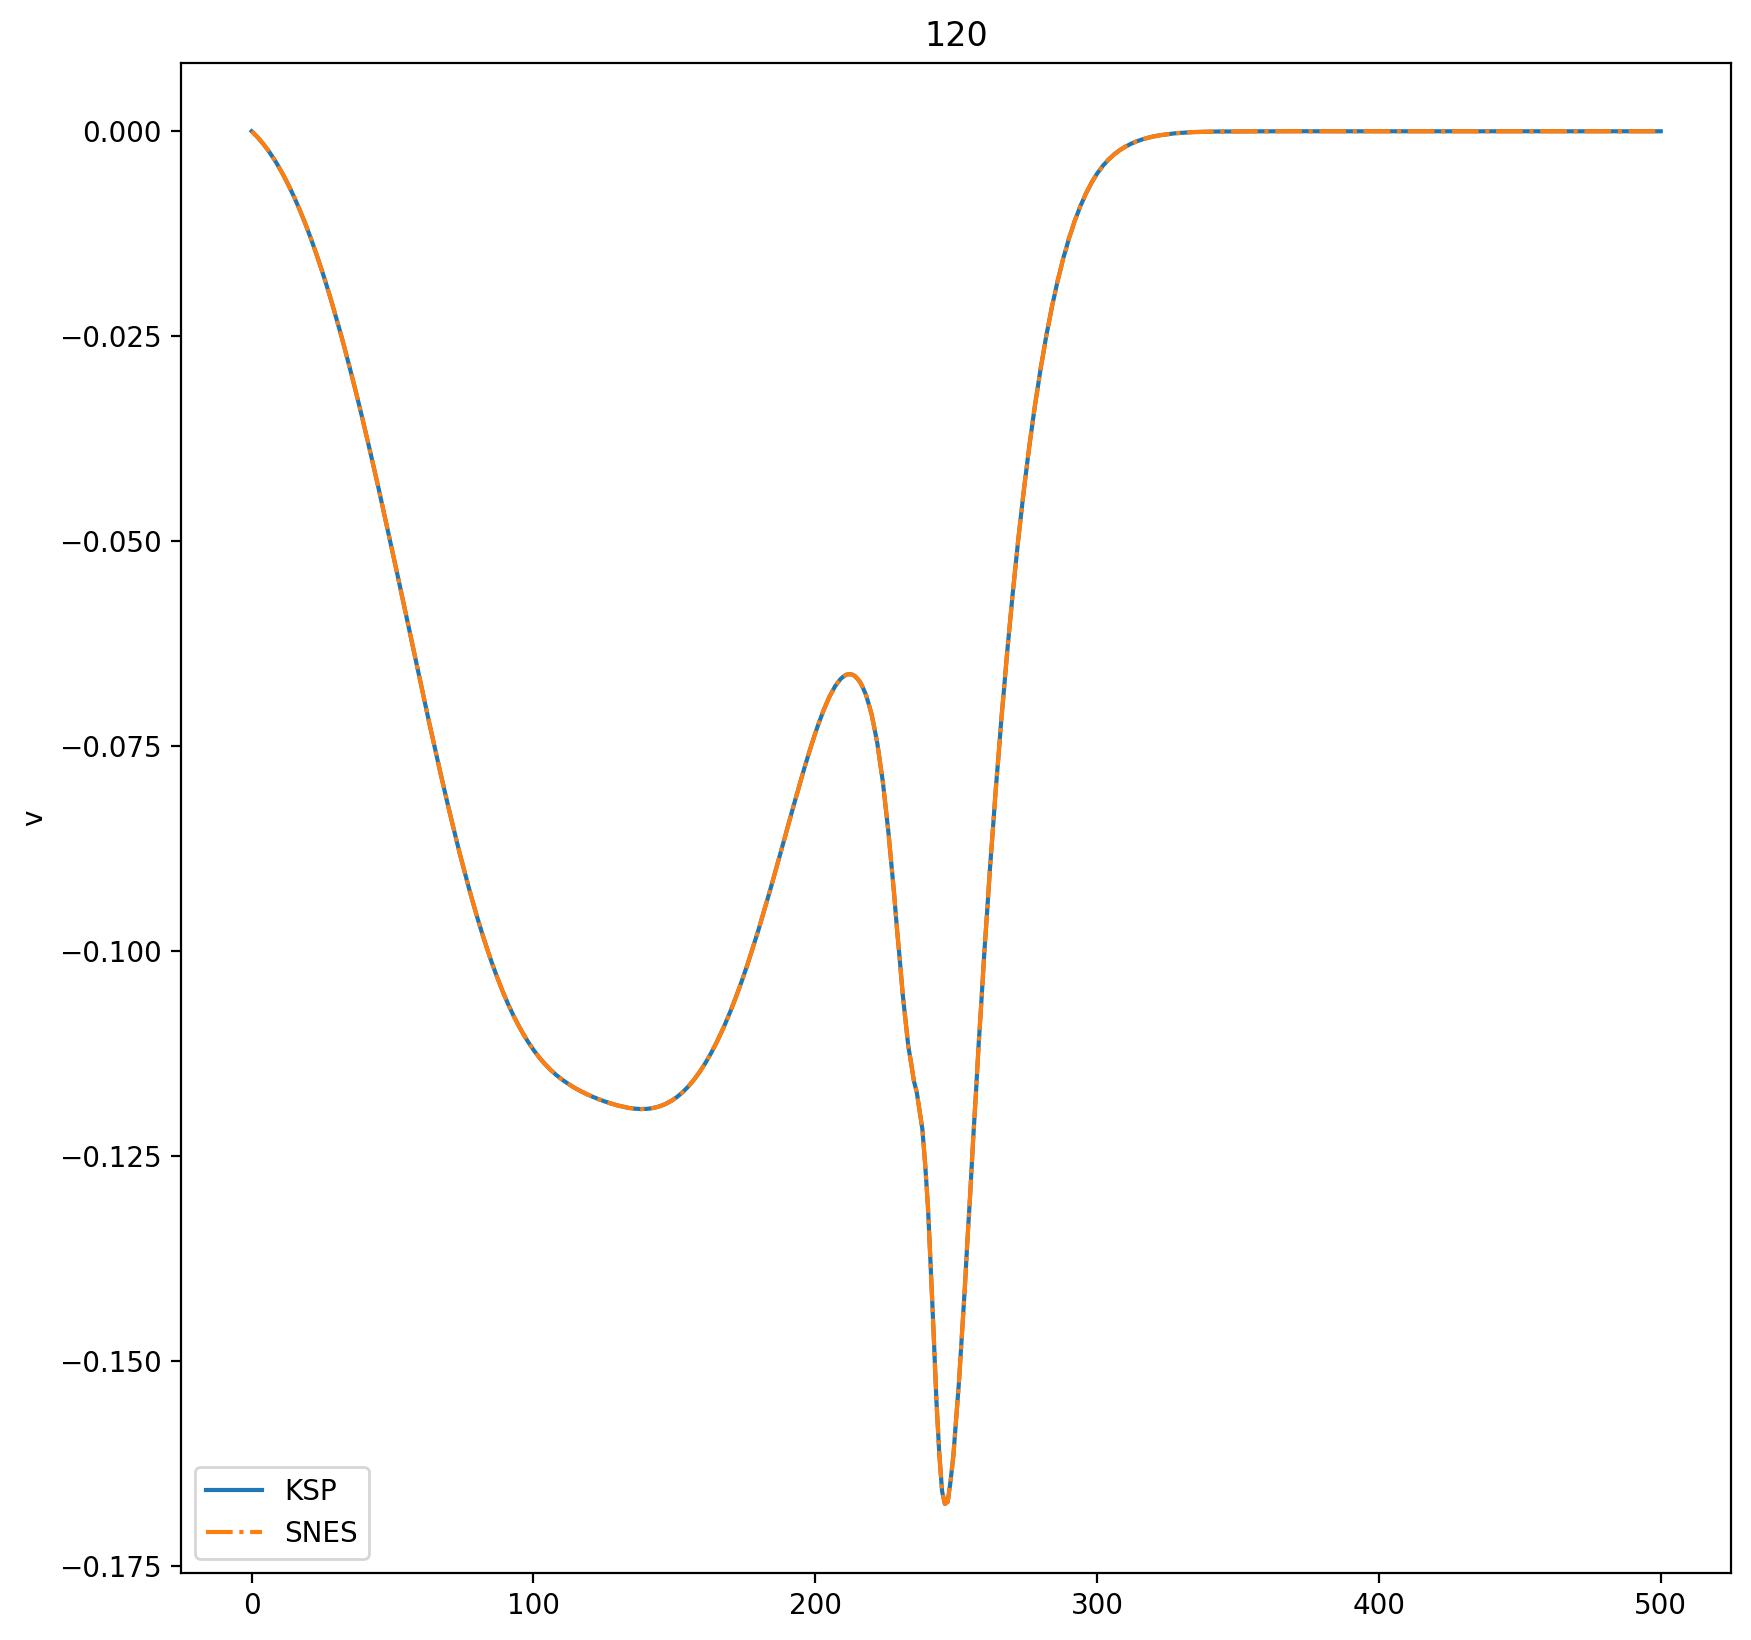

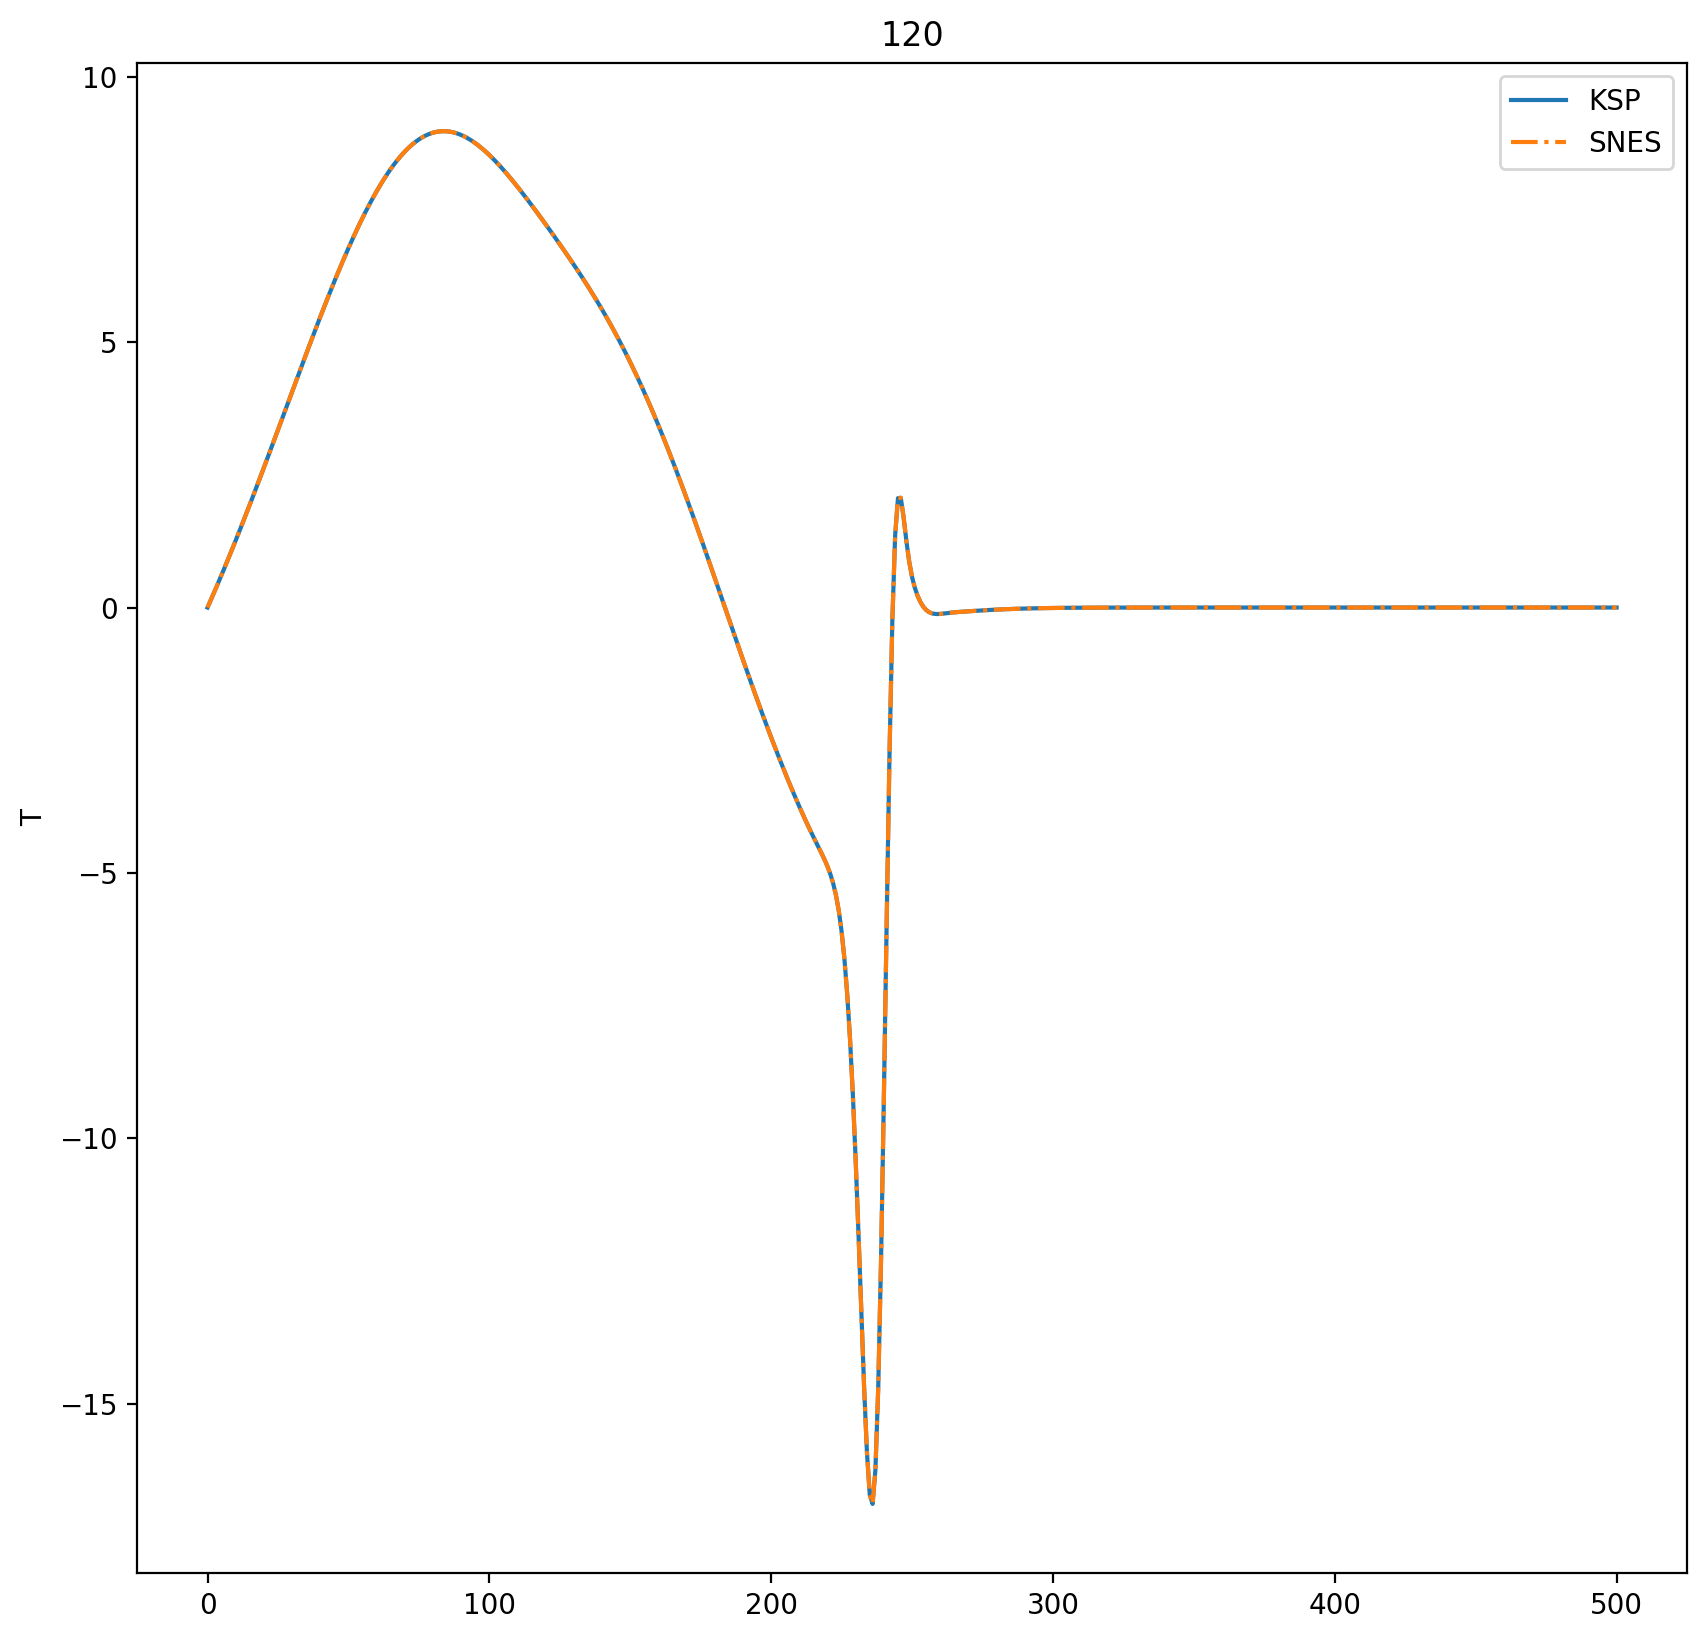

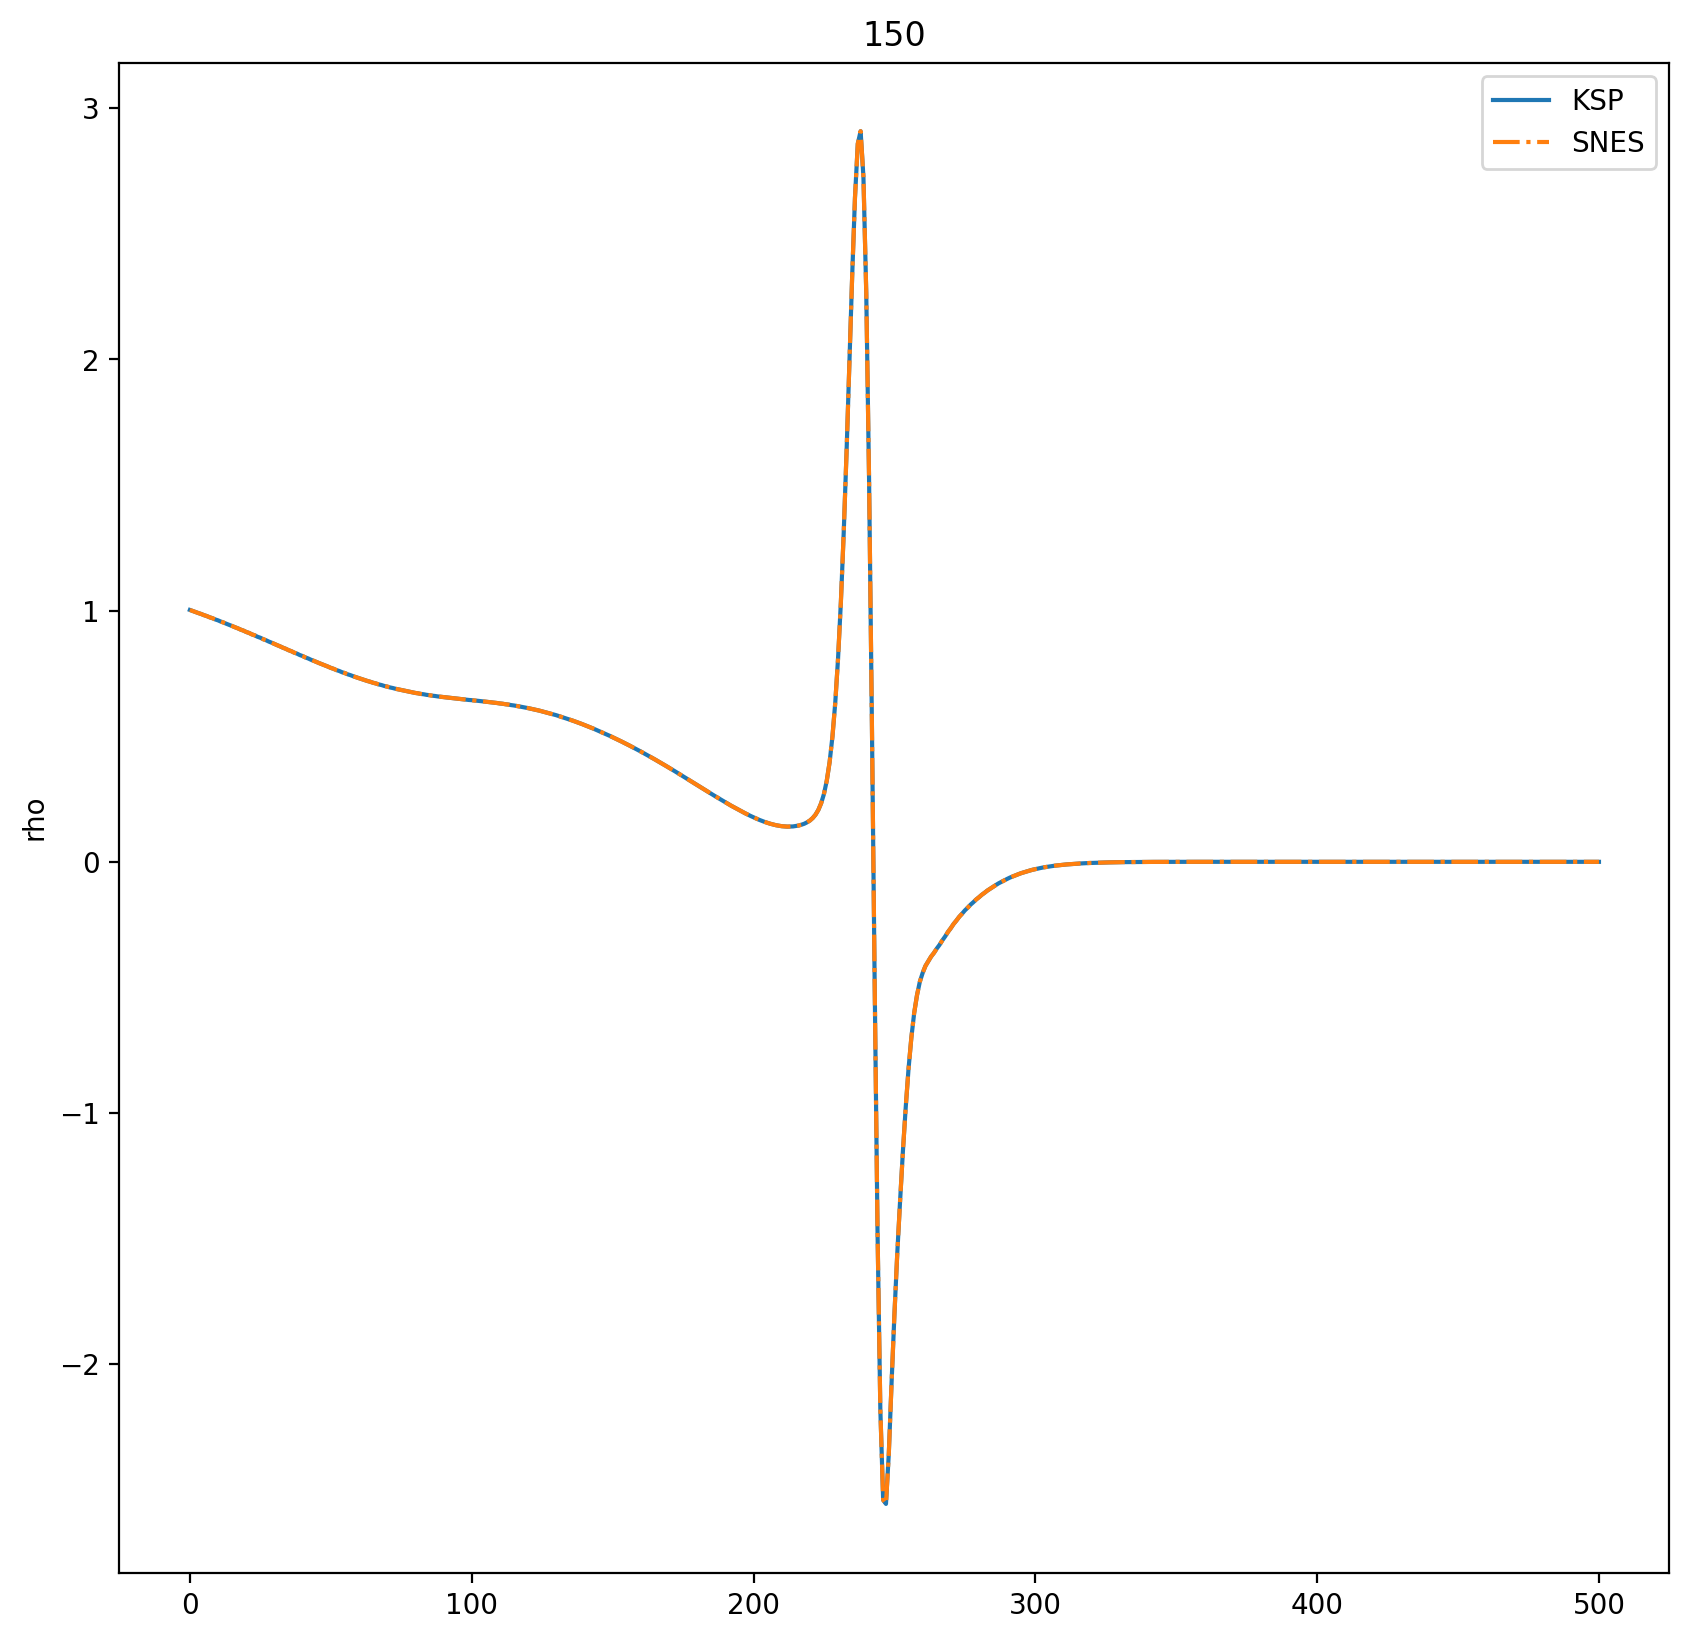

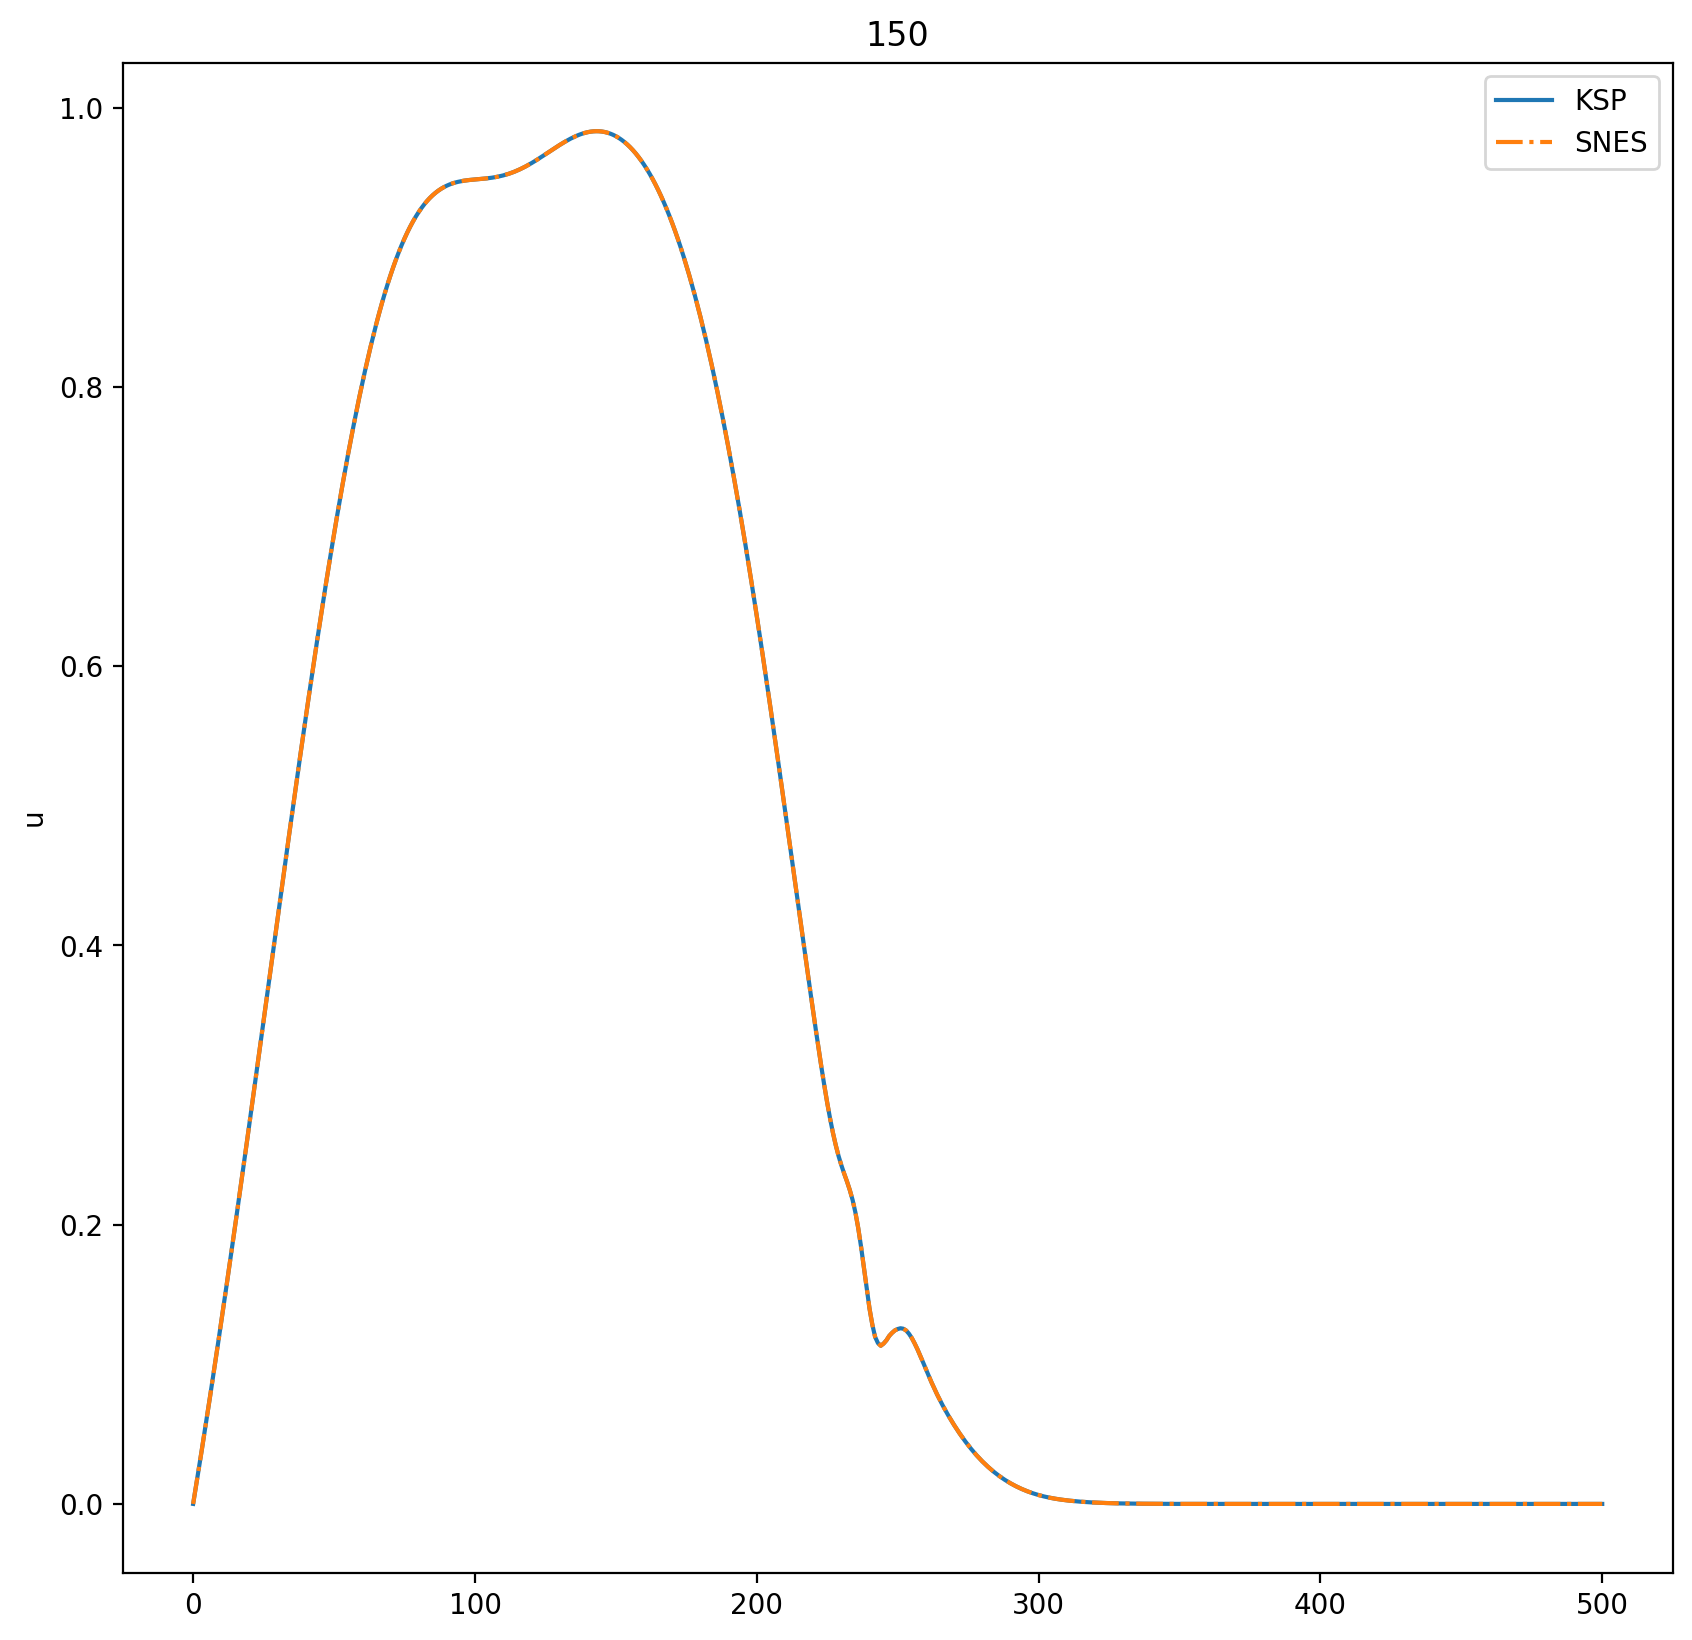

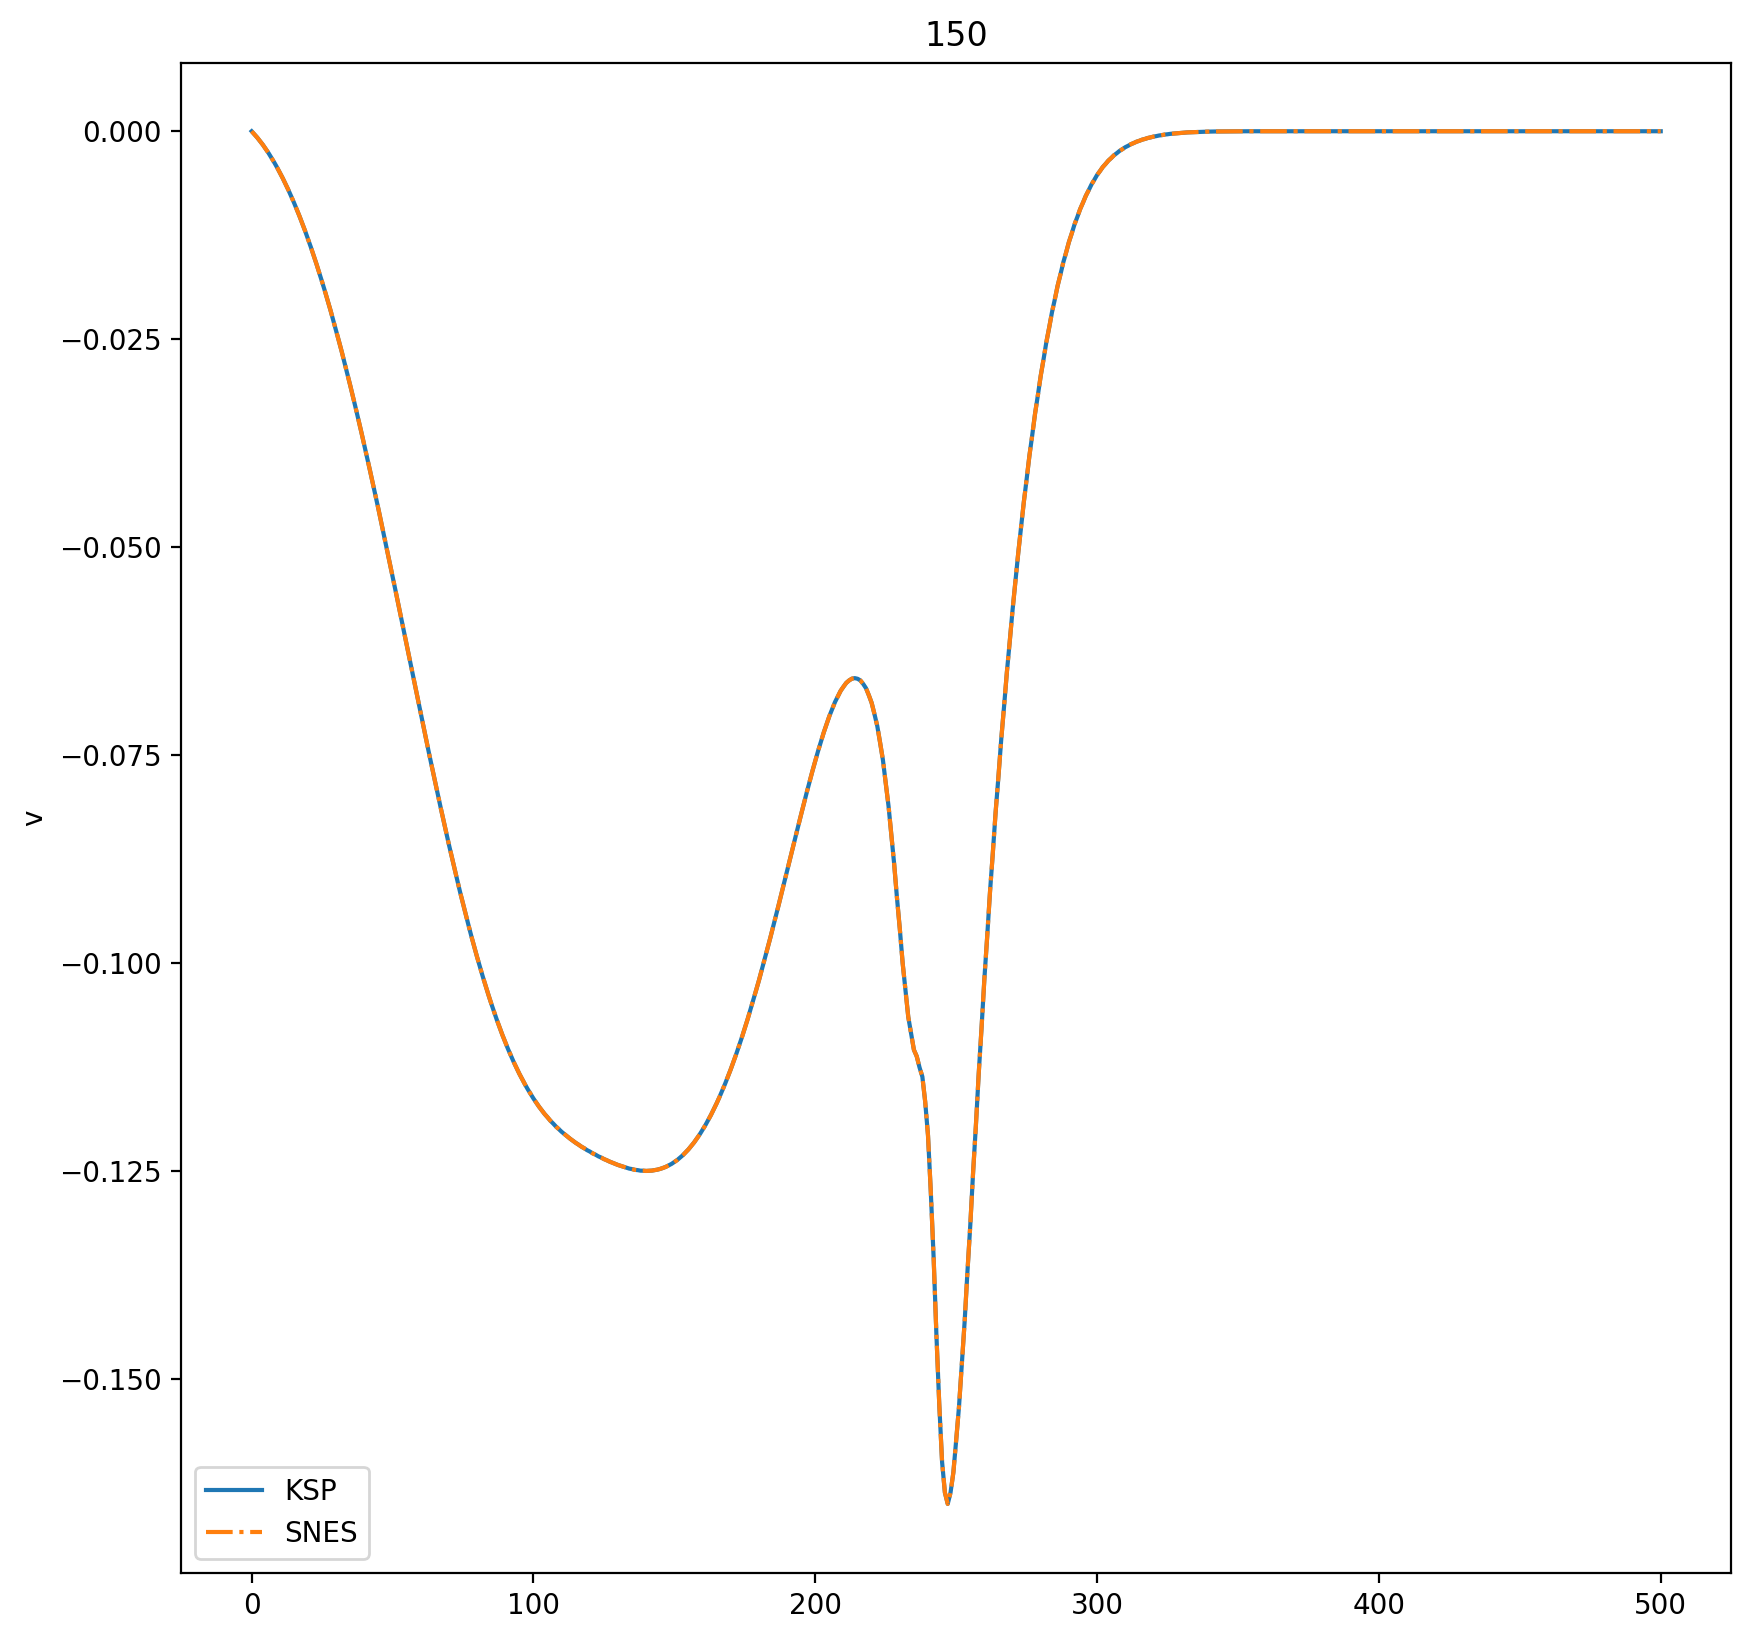

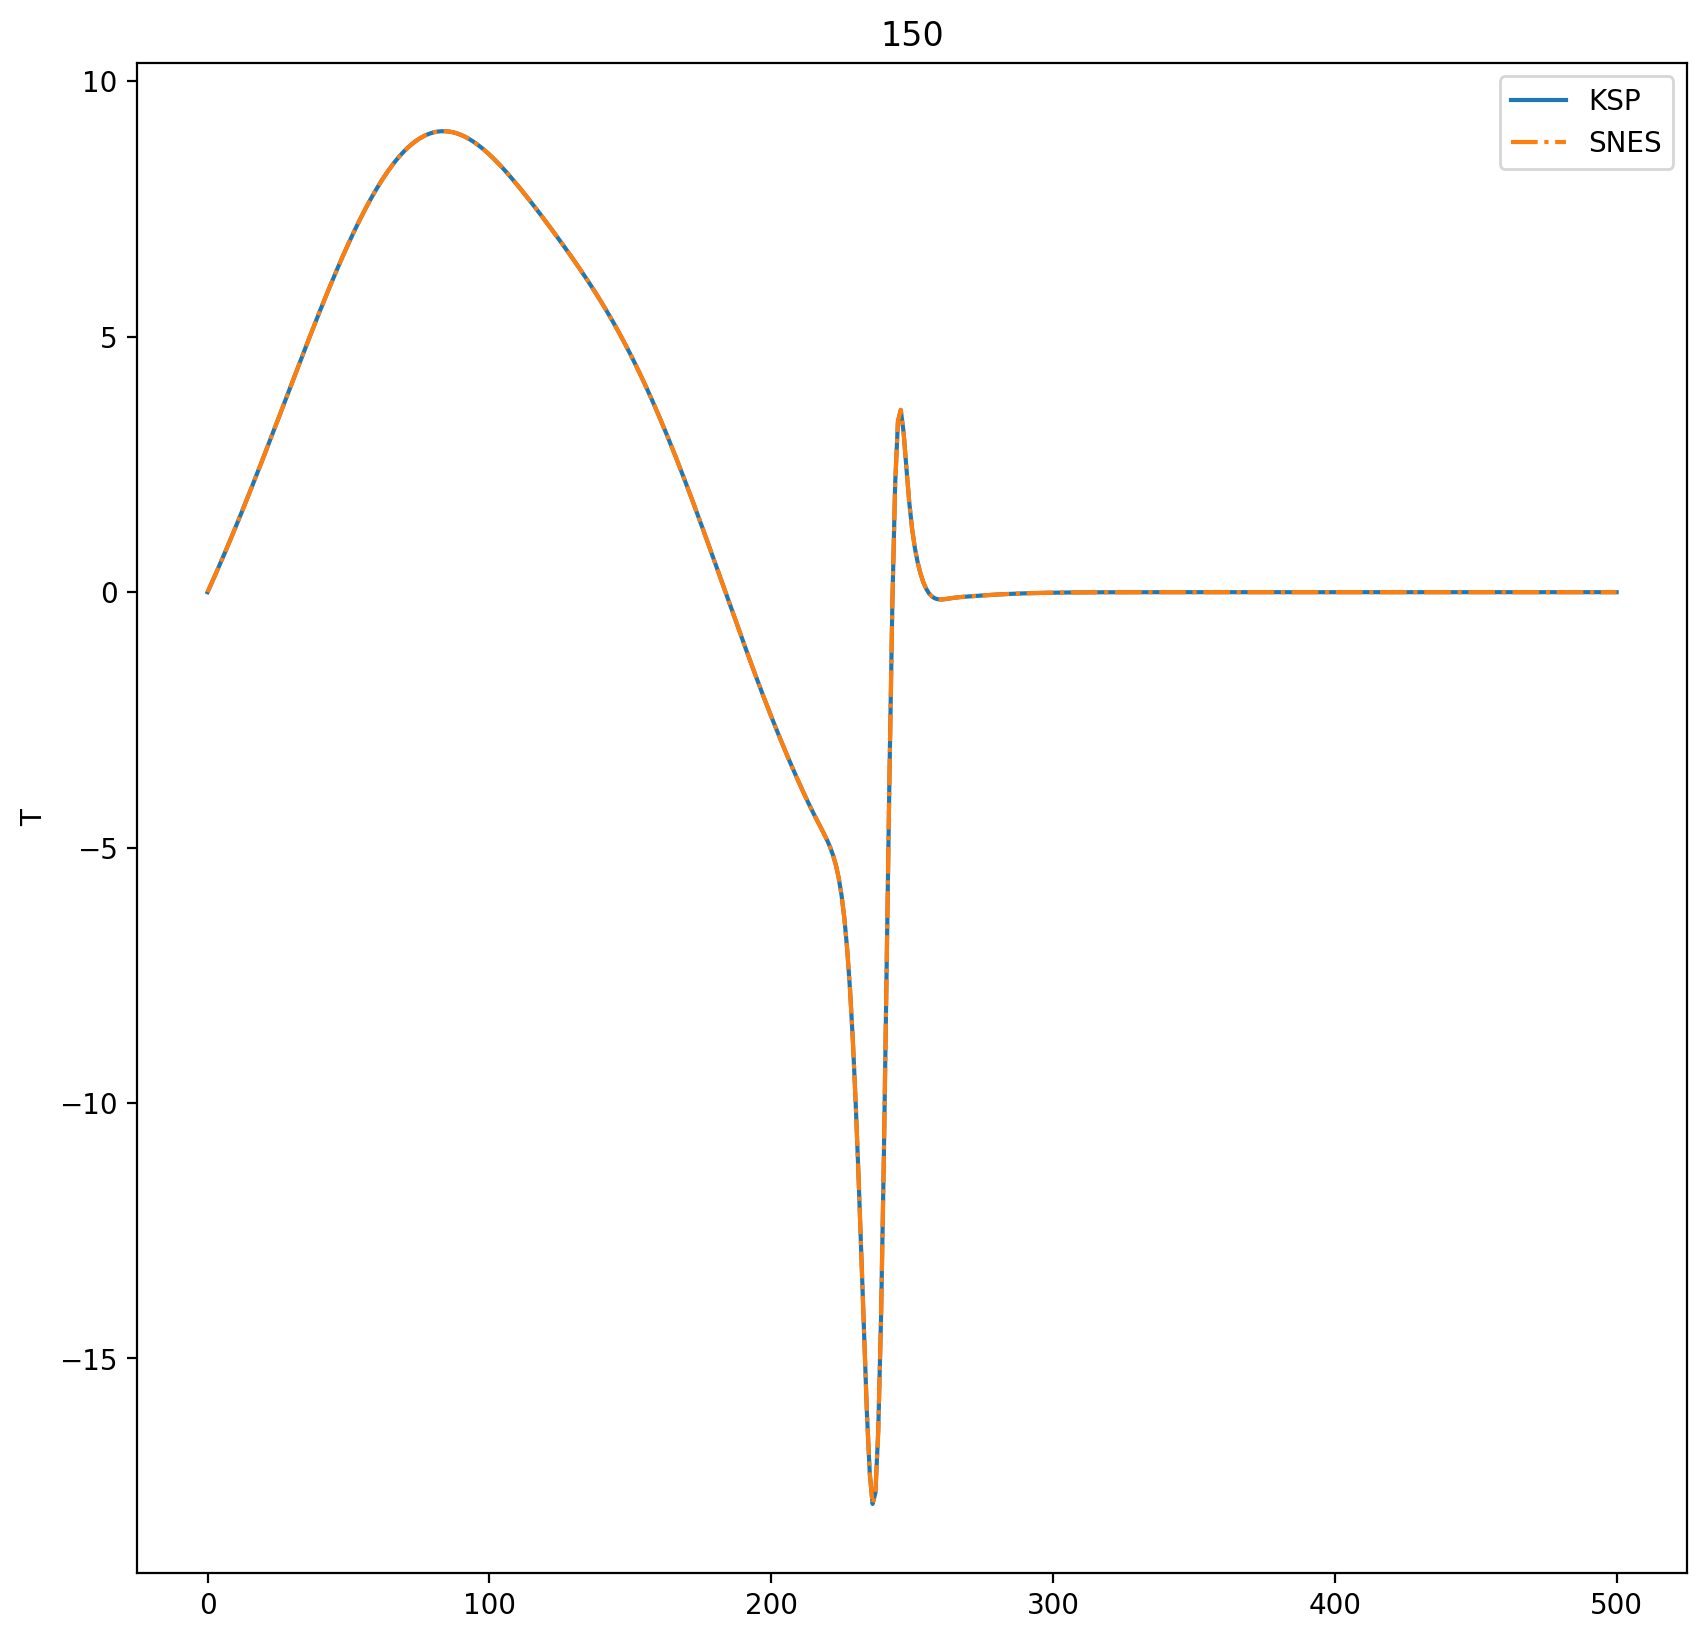

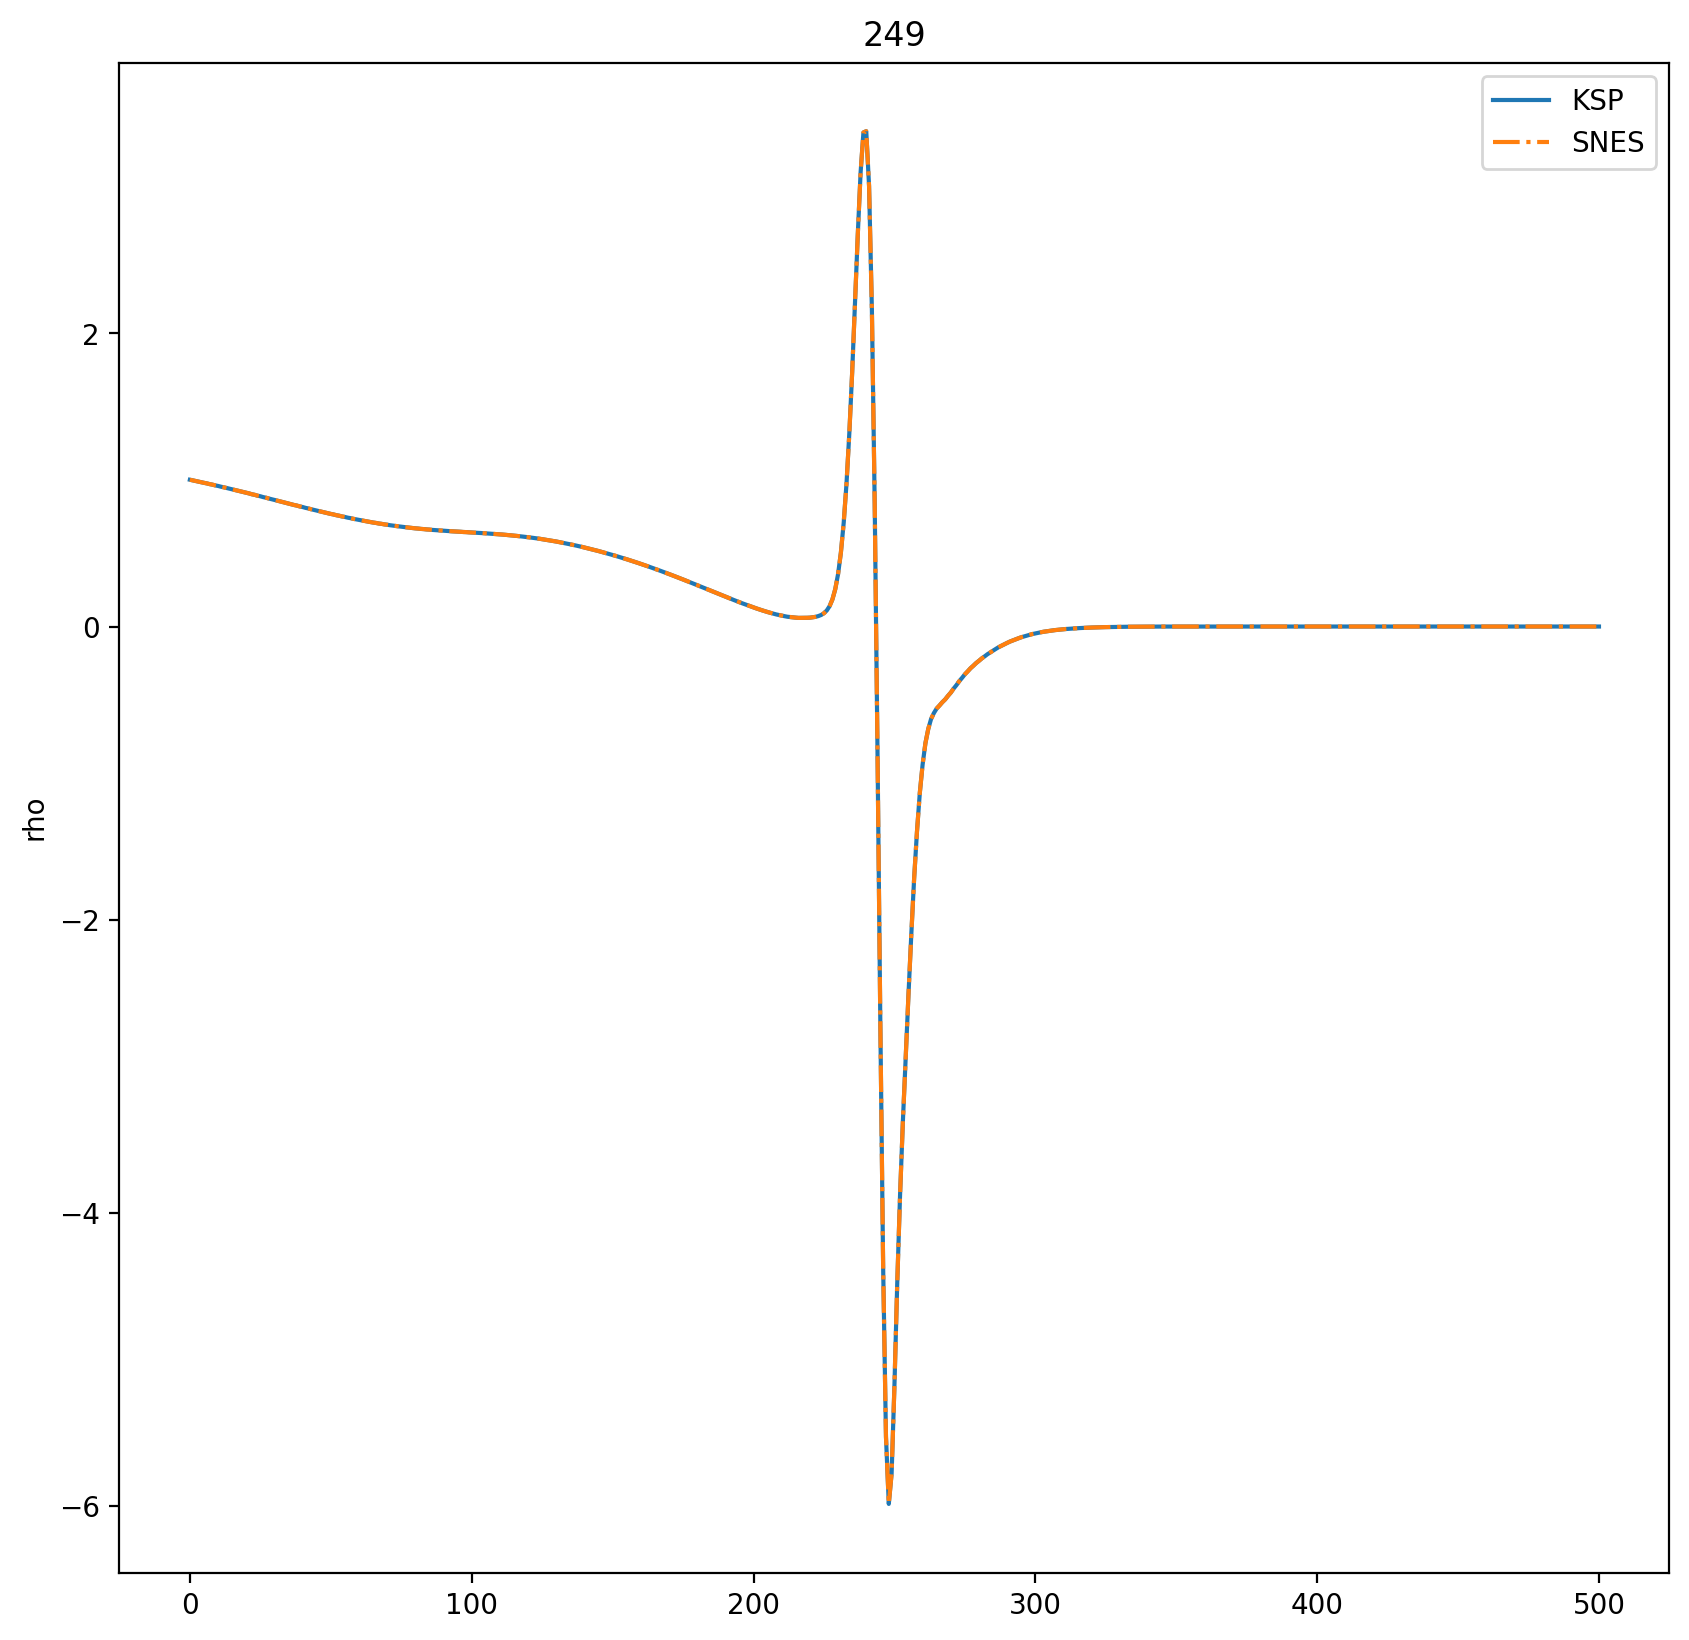

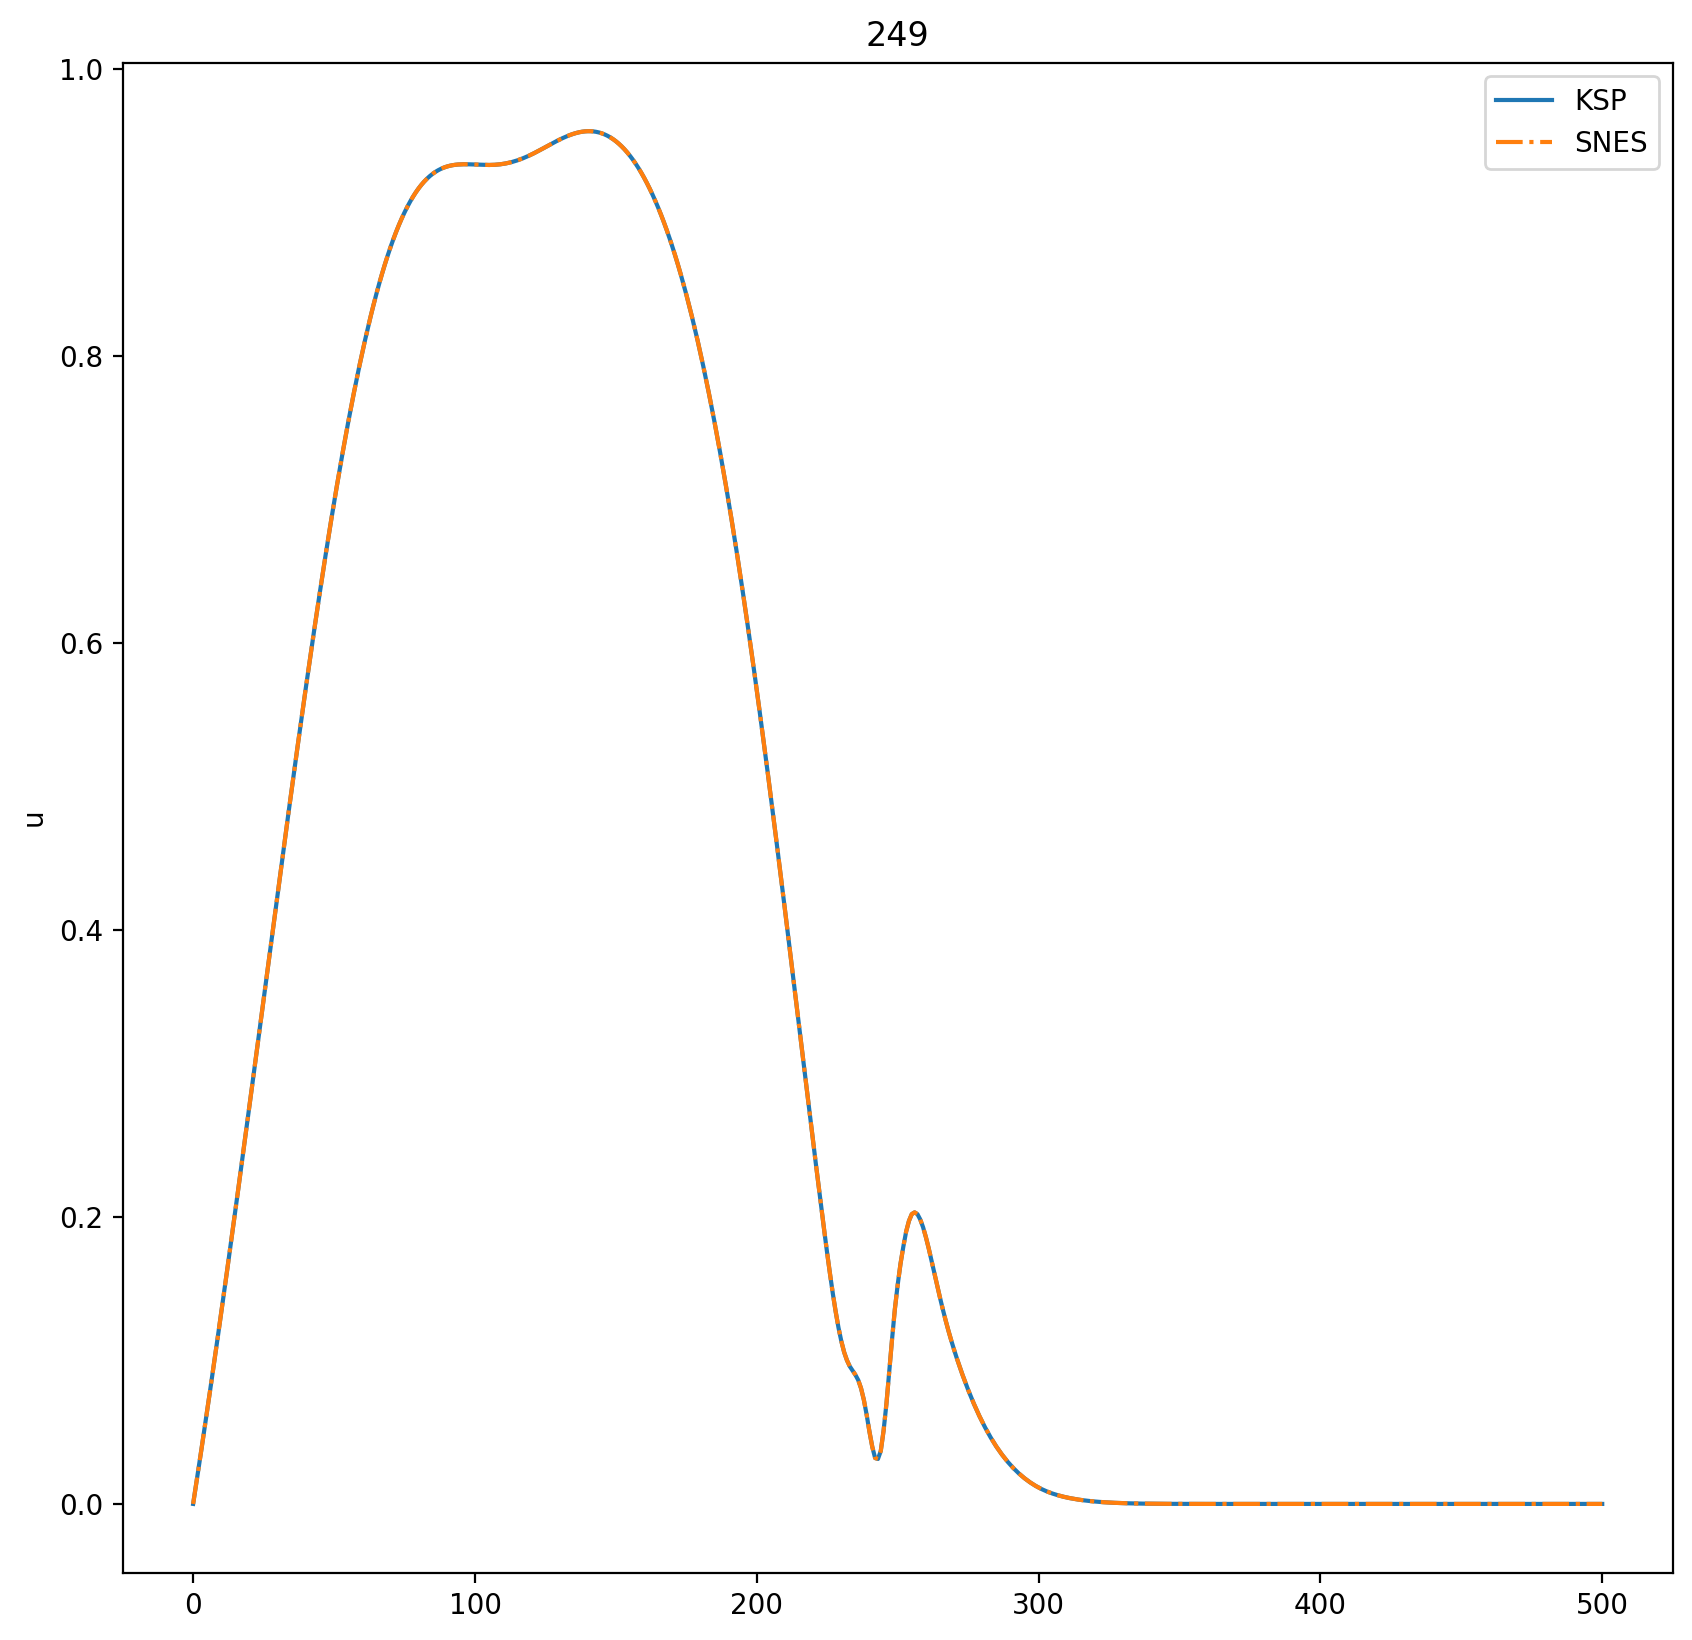

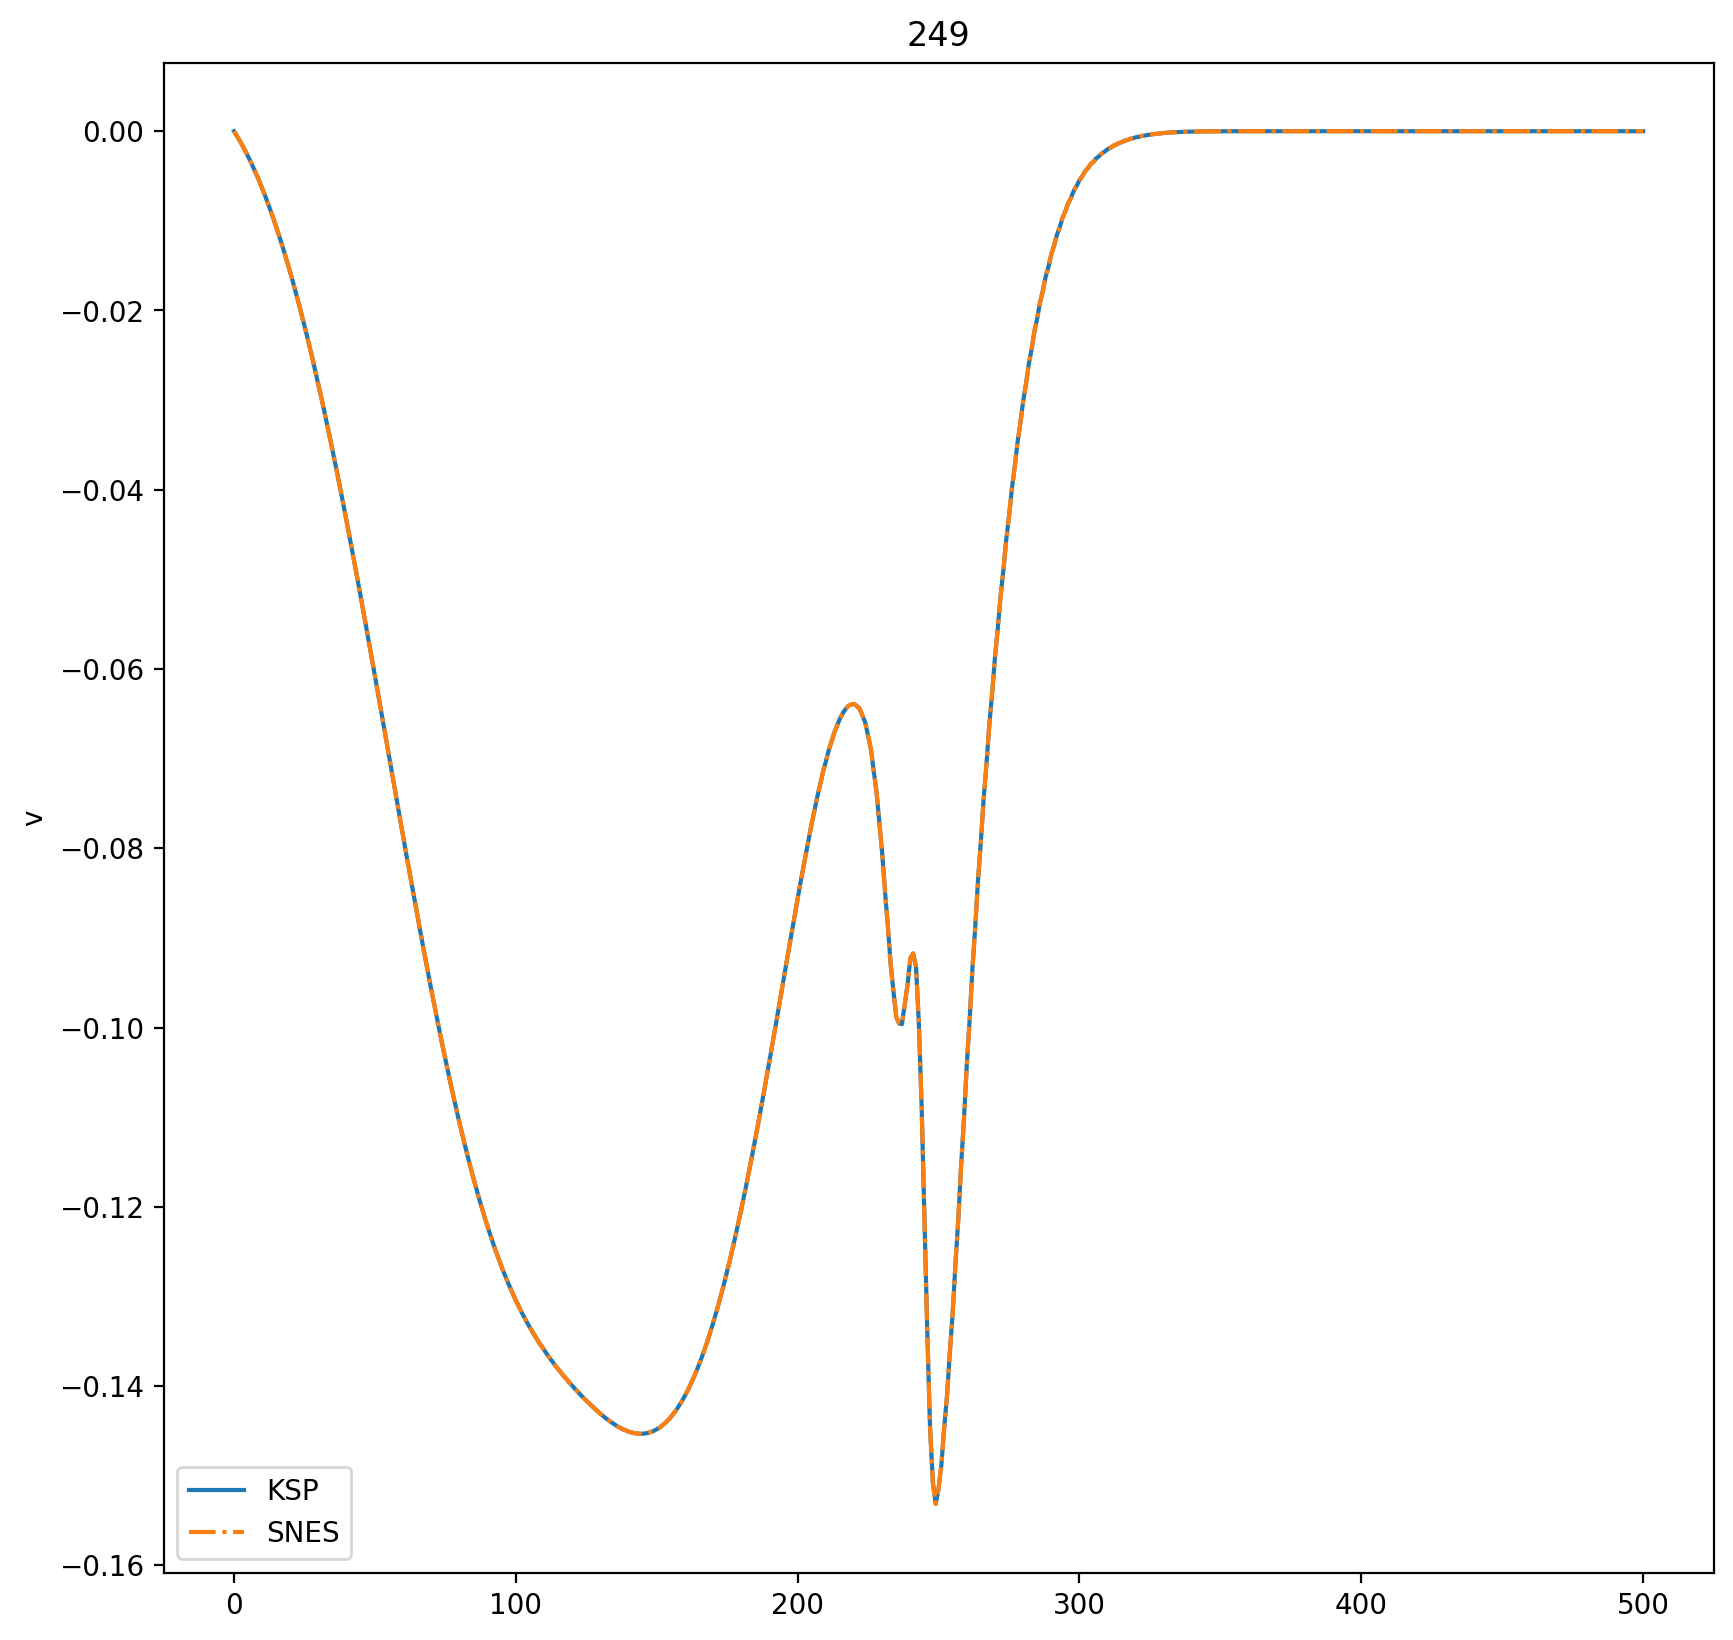

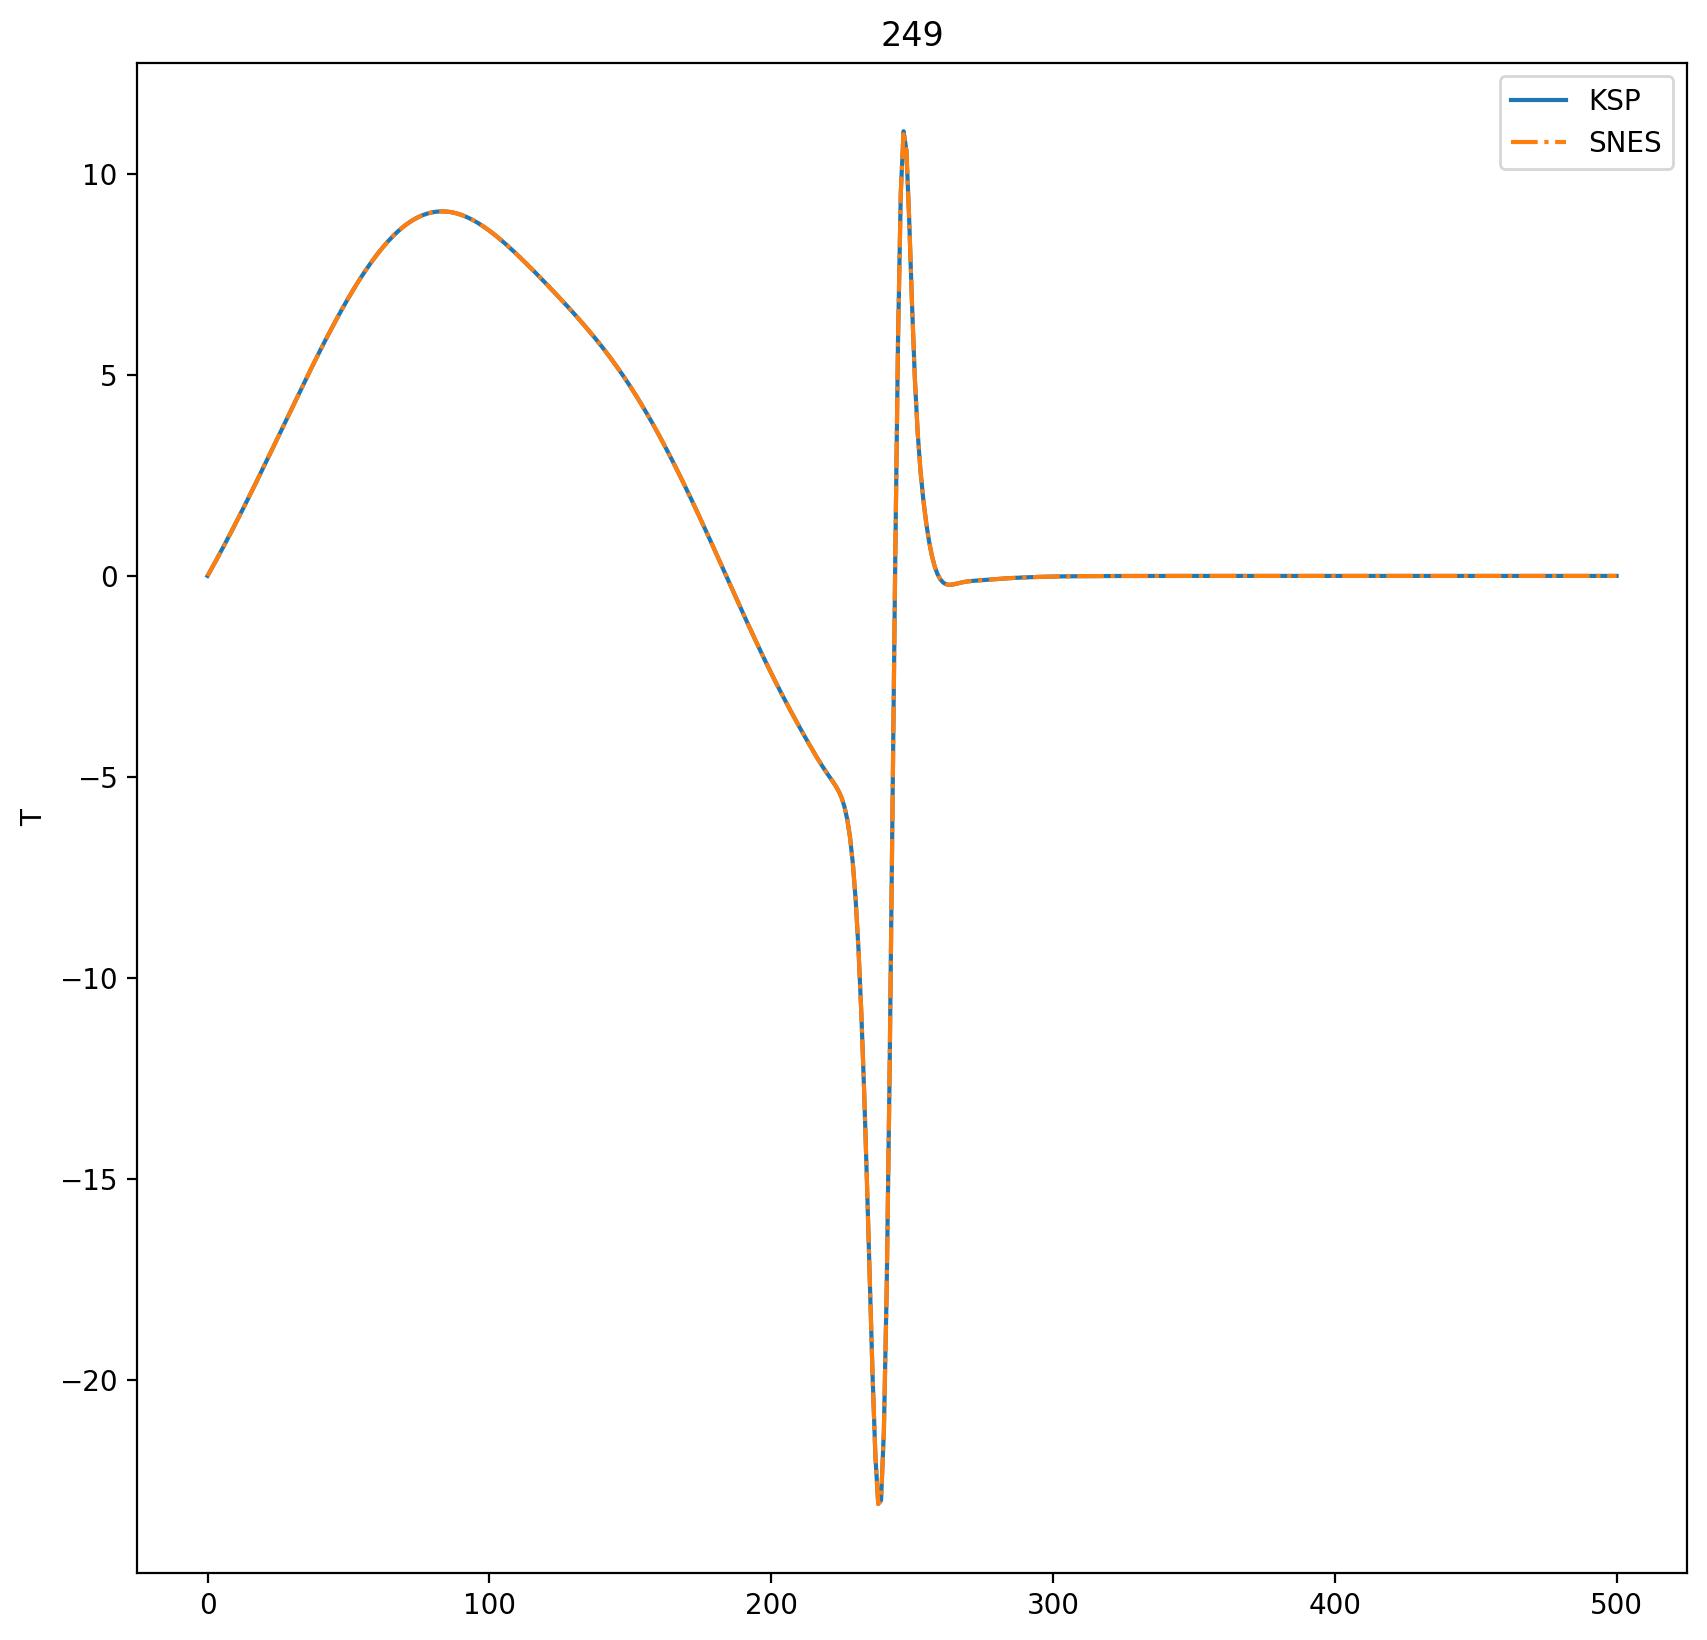

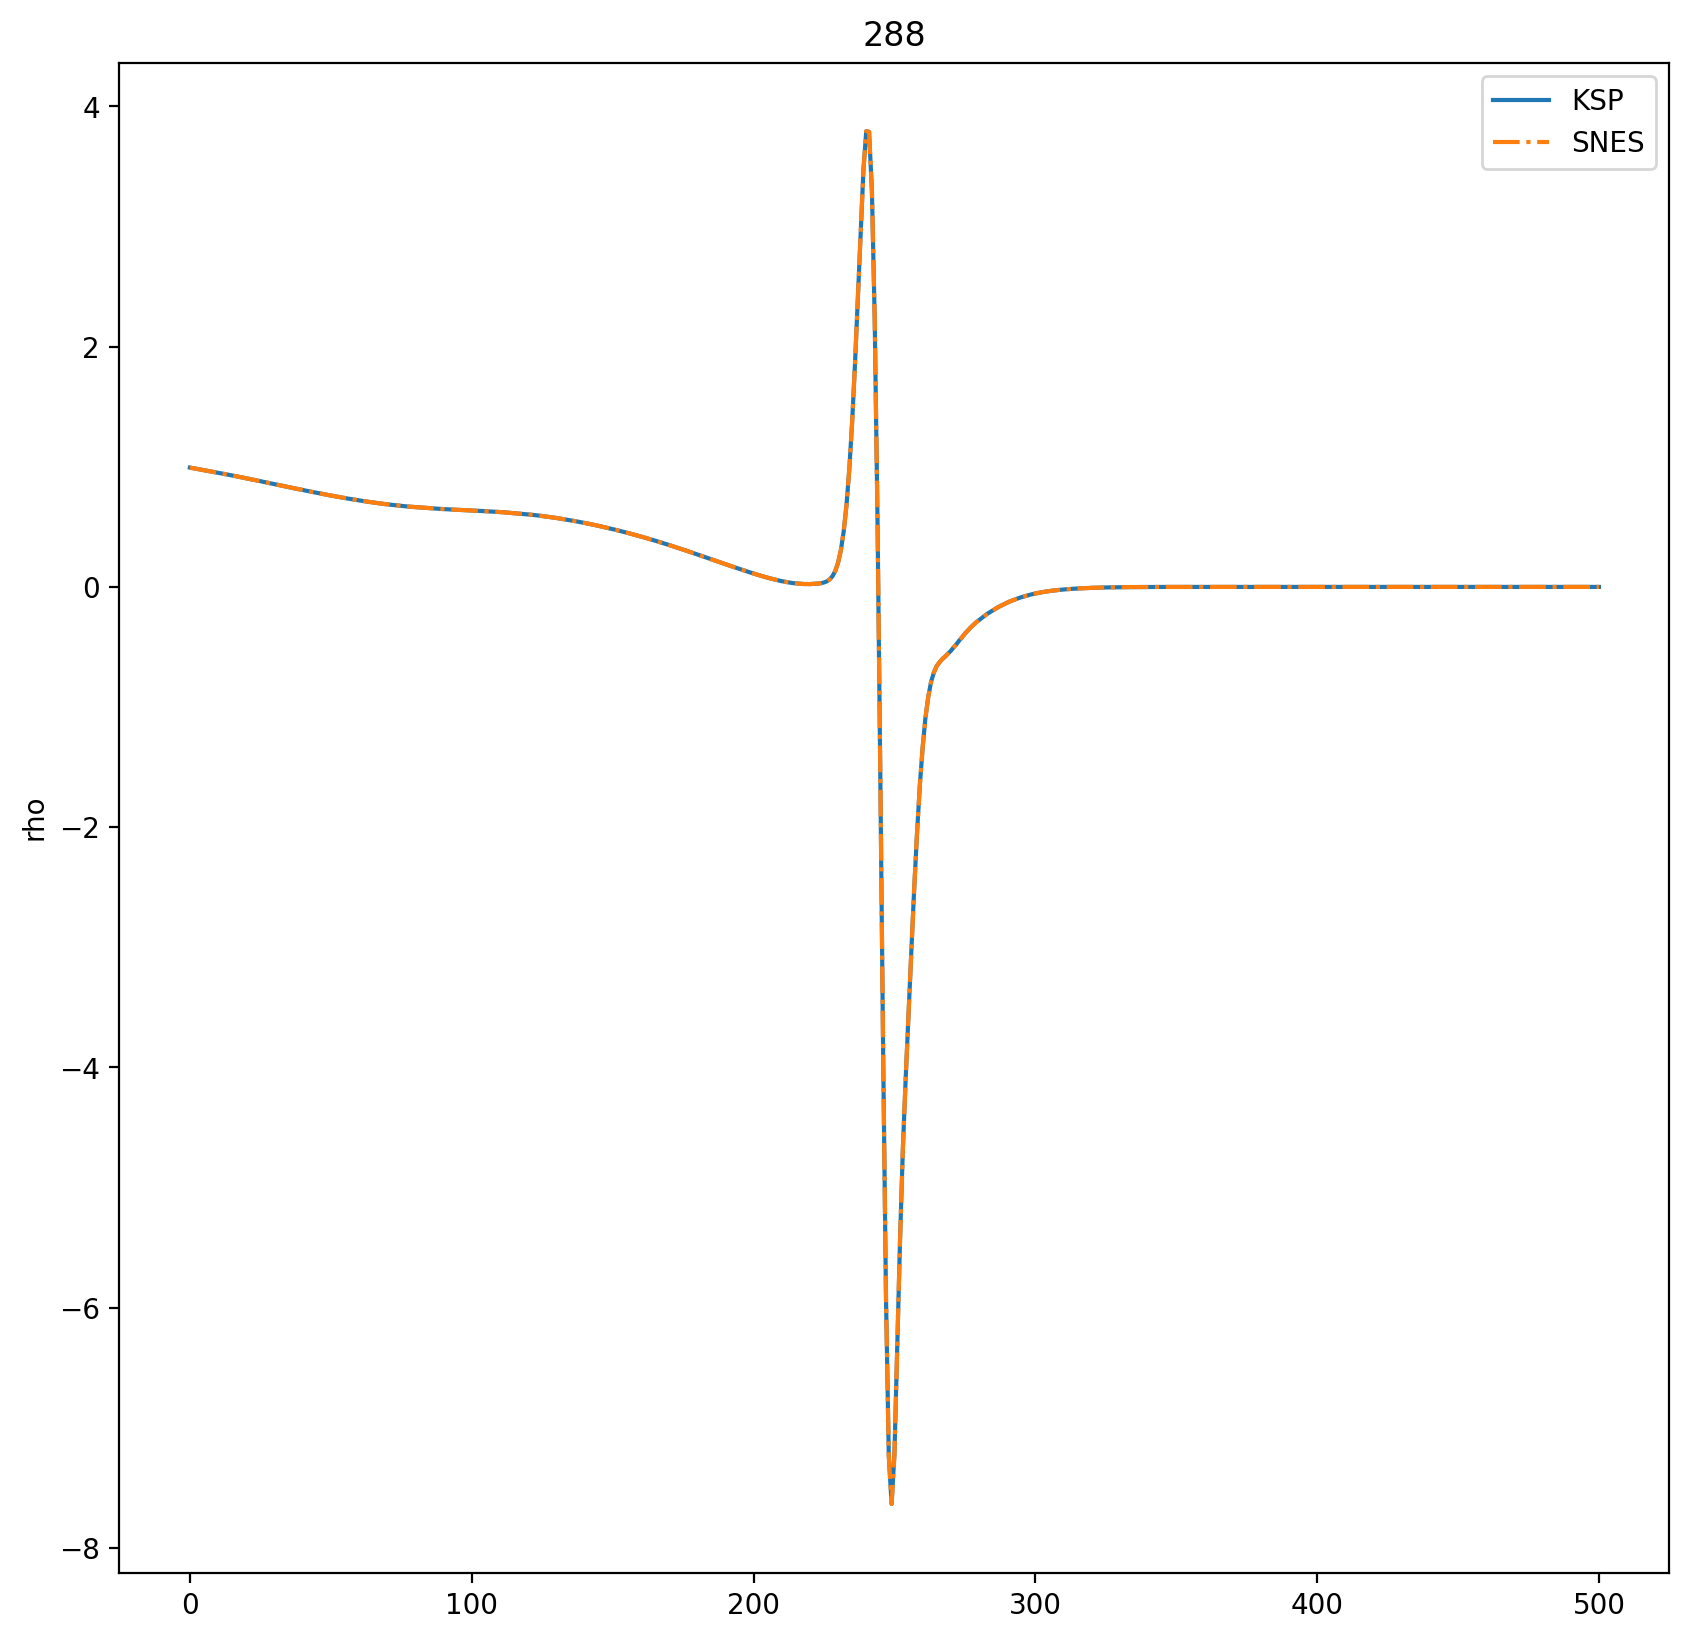

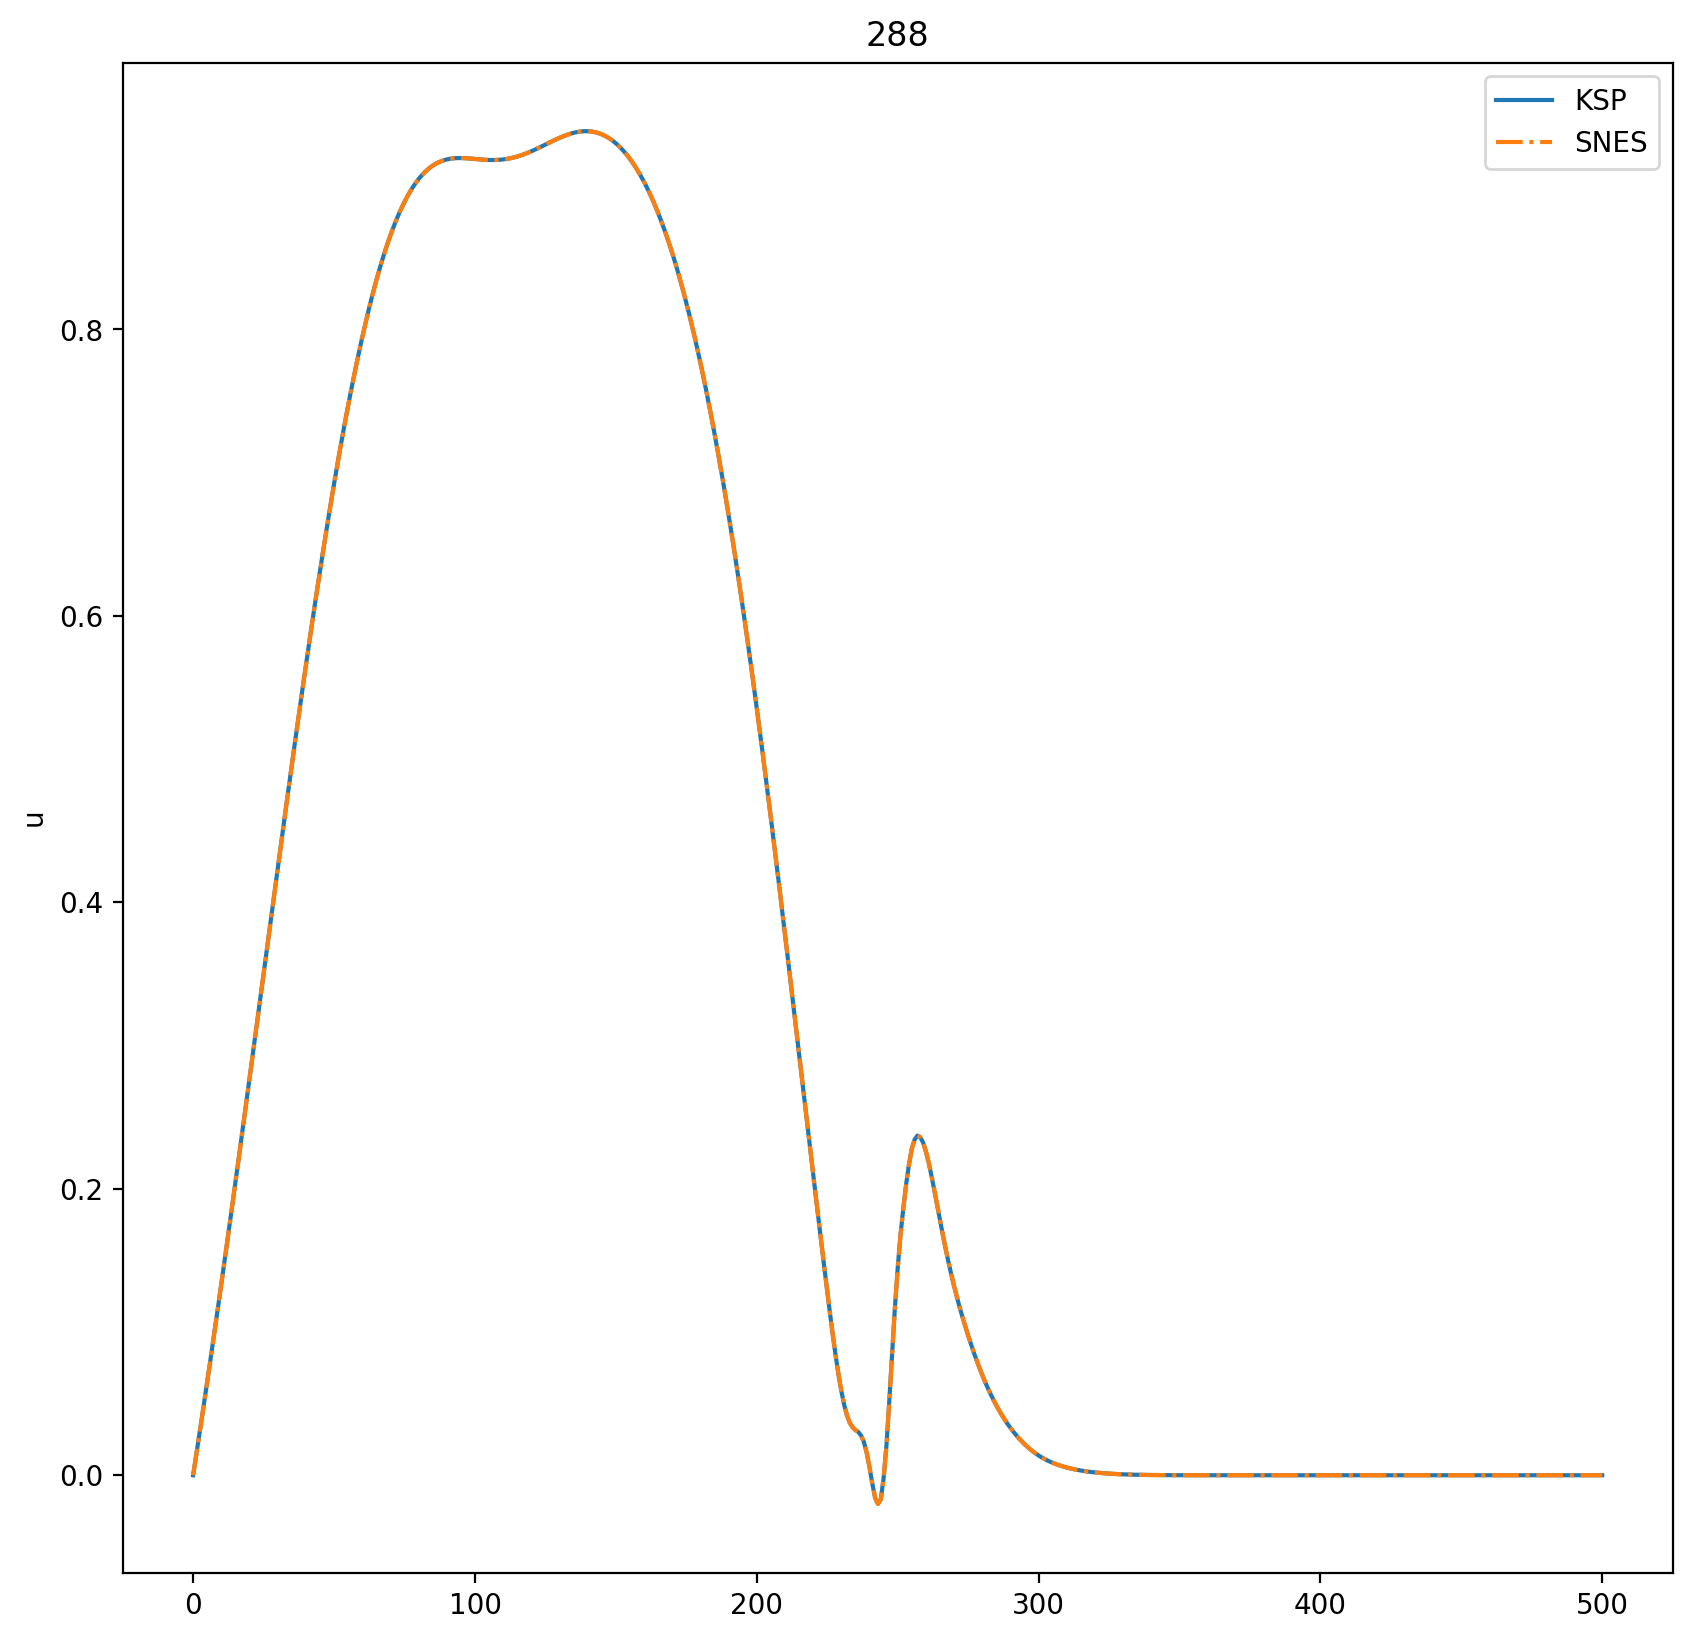

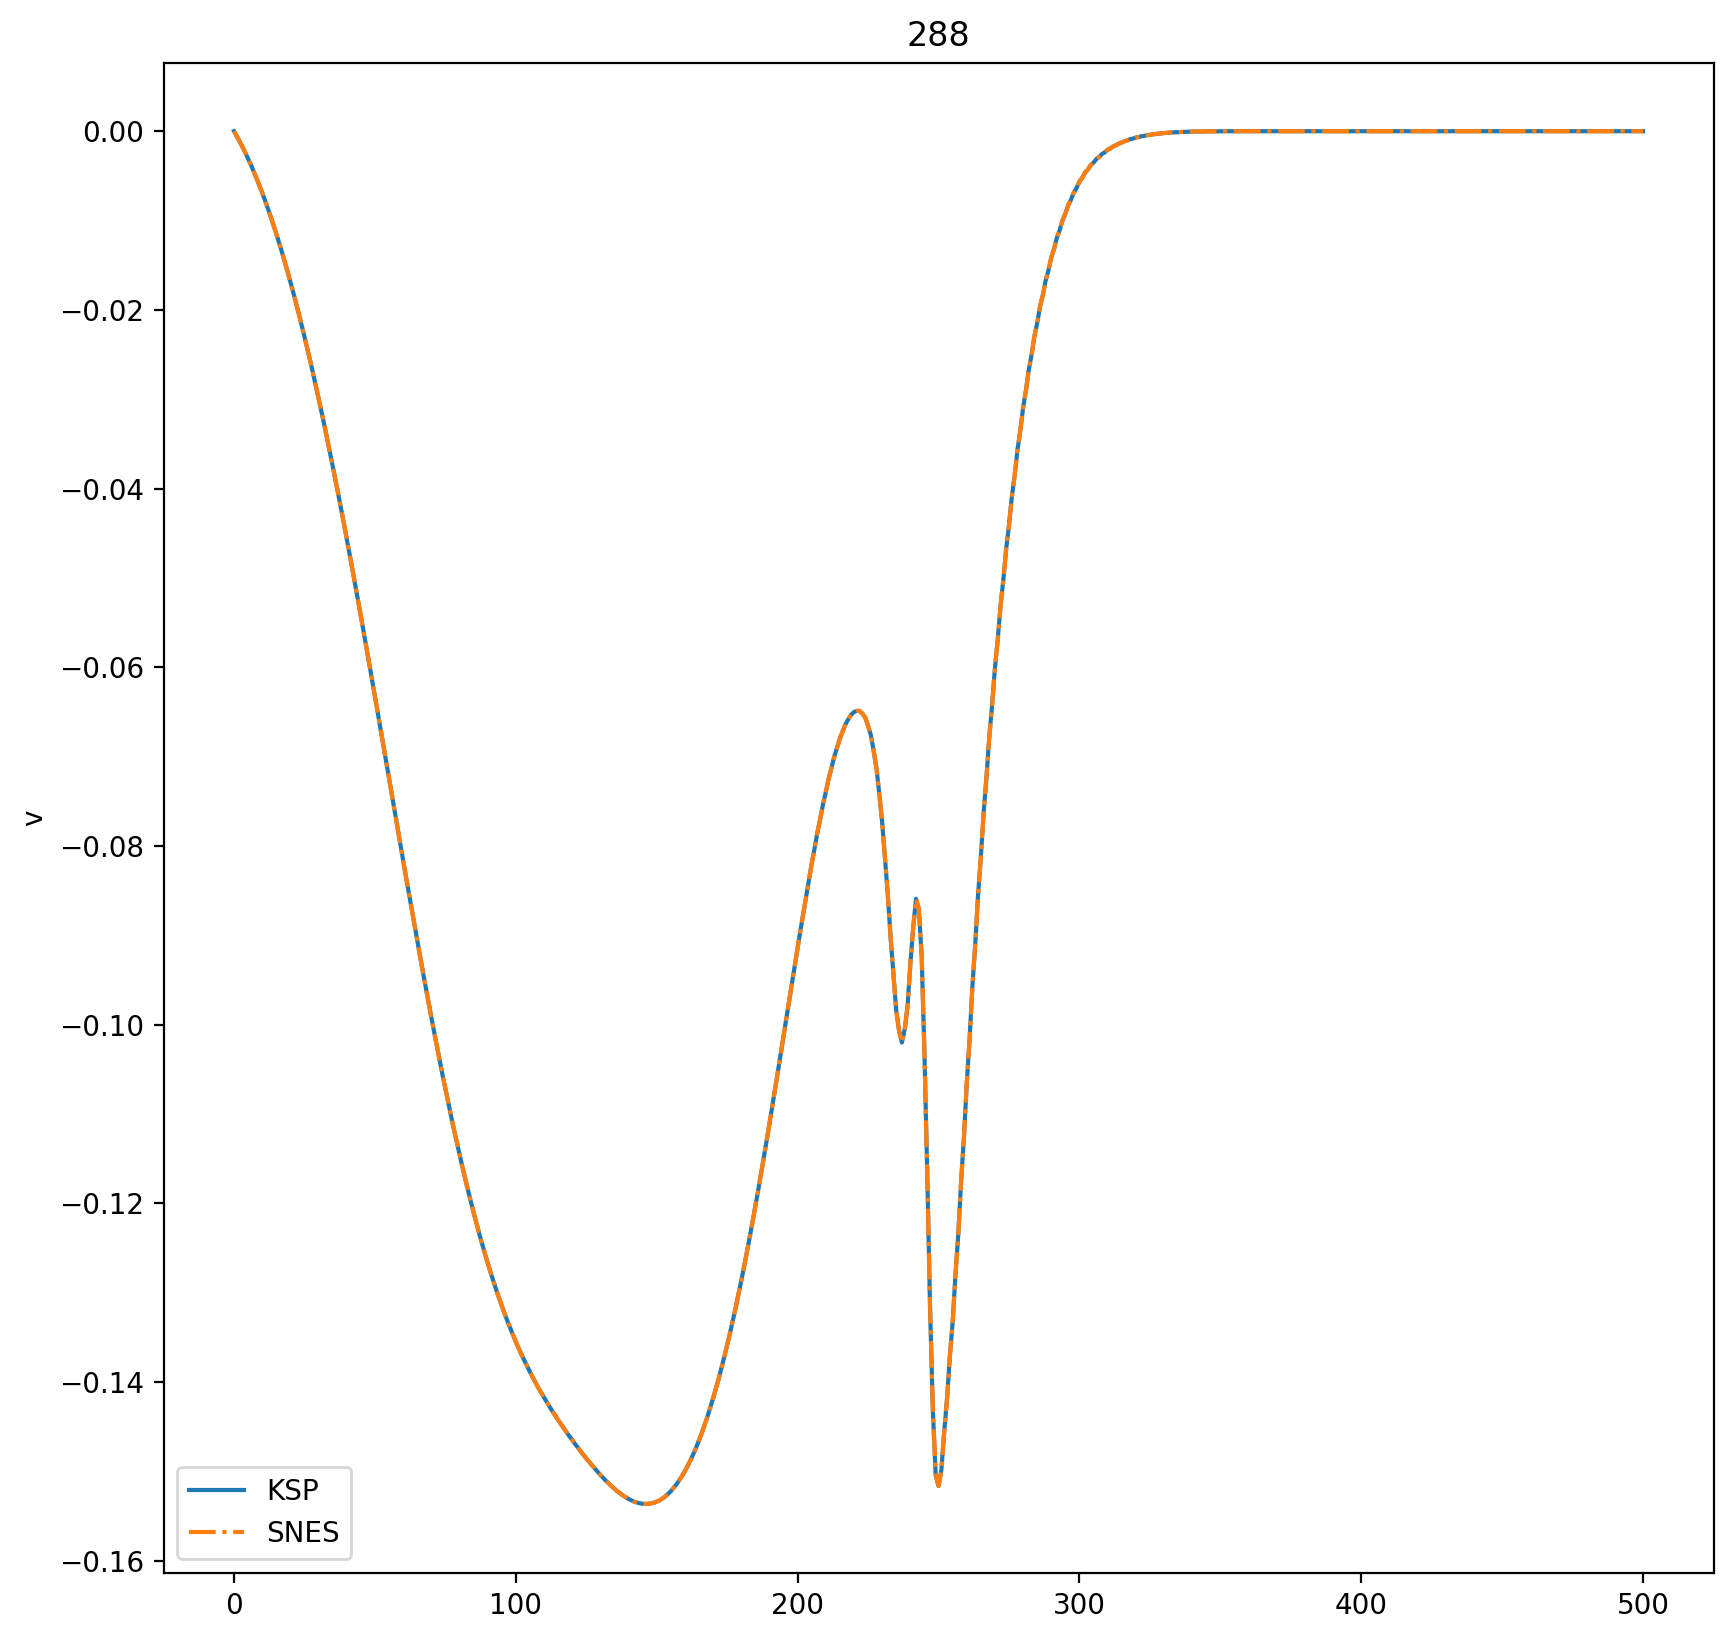

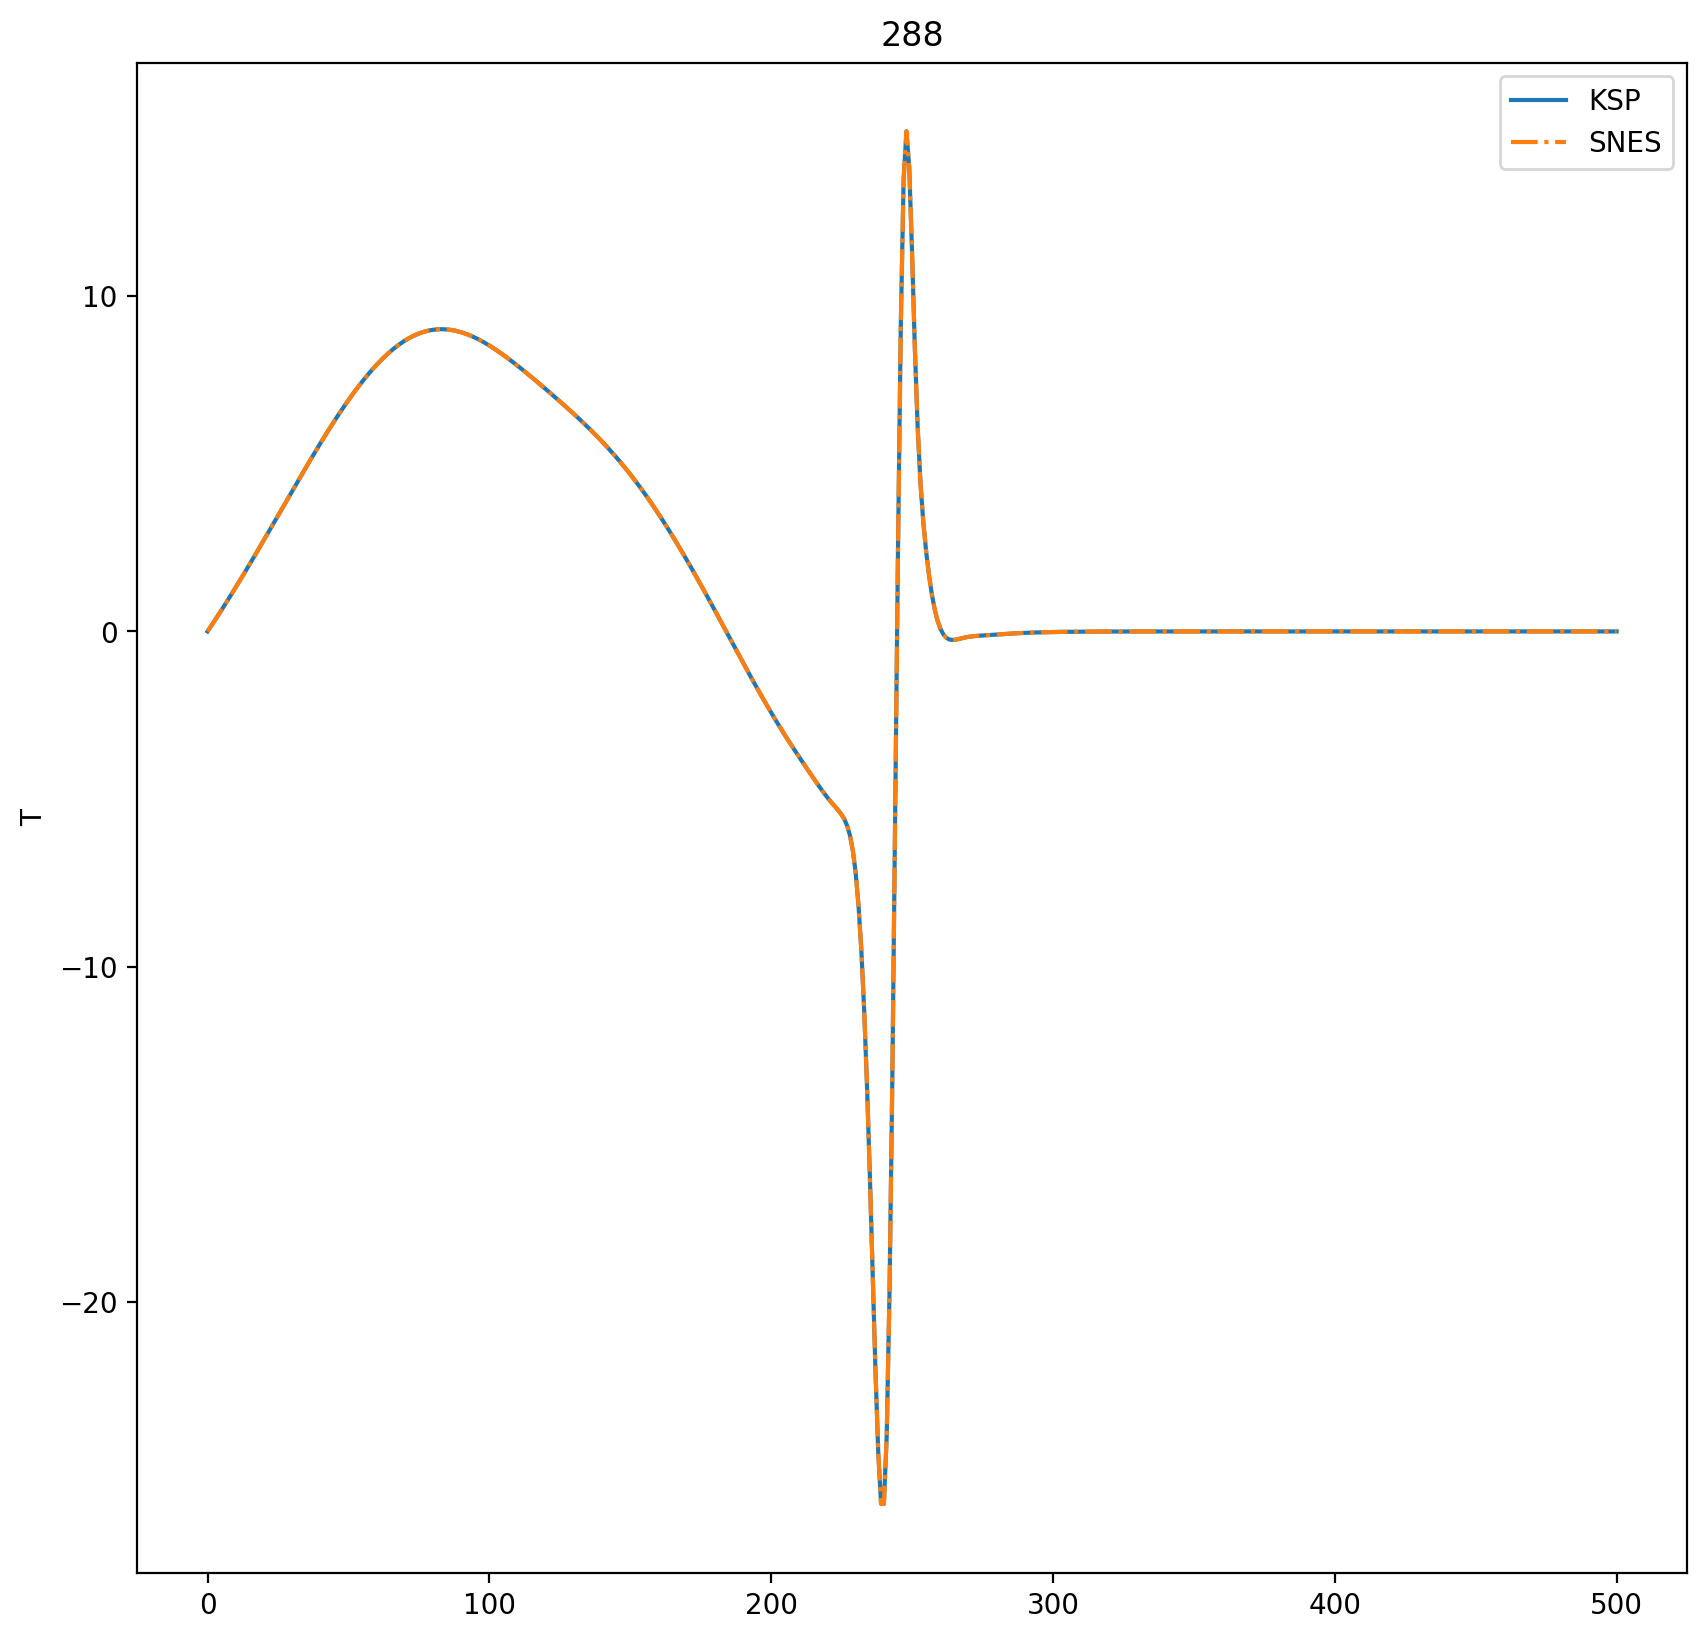

In [7]:
dic = ('rho', 'u', 'v', 'w', 'T')
for m in [40,120,150,249,288]:
    for c in [0,1,2,4]:
        plt.figure(figsize=(10, 10), dpi=200)
        plt.plot(p_result[c,m,:,0].real, label='KSP' , linestyle="-")
        plt.plot(h_result[c,m,:,0].real, label='SNES', linestyle="-.")
        plt.title(str(m))
        # plt.scatter(hor, drt2, c='deeppink', label='LPSE', s=1)
        # plt.title("HLNS")
        # plt.xlabel("x")
        plt.ylabel(dic[c])
        plt.legend()
        plt.show()